# Time-resolved trajectories of Clip subcategories

Replicates the design of experiment 2 (per-area, per-stim trial-averaged trajectories with the time axis preserved) but **inside the Clip stimulus class**, using the three content categories MICrONS already labels (`Cinematic` / `sports1m` / `Rendered`).


## How to use this notebook

Pipeline is **session-swappable**: change `SESSION` in the configuration block below and restart the kernel.

## Part 0: Setup

In [1]:
import os
from pathlib import Path

# The notebooks import `scripts.*` and write `figures/…`, `results/…`
# relative to the repo root. If the kernel was started inside `notebooks/`
# (JupyterLab default), move up one level so both resolve.
if not Path("scripts").is_dir() and Path("../scripts").is_dir():
    os.chdir("..")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import scripts.microns_eda as microns_eda
# Used in Part 2 below.
import scripts.experiment1_utils as pca_utils
import scripts.experiment2_utils as traj_utils
import scripts.experiment3_utils as o4

In [2]:
# Apply the presentation palette + white-background style globally.
from scripts.neuro_palette import apply_style
apply_style()

### Configuration

We run the label-permutation null with `N_SHUFFLES = 1000` (no bootstrap band is drawn: a bootstrap of a Euclidean distance between noisy means is centred above the observed curve, so the band reads as a plotting error; the dashed bias-corrected curve replaces it). Each pairwise significance call compares the observed maximum against its null's 95th percentile; the CSV also carries `p_holm`, the Holm-adjusted p-value over the 12 tests (4 areas × 3 pairs) of each metric. An empirical p cannot go below `1/(N_SHUFFLES+1)`; with 1000 shuffles the floor is 0.001, below the smallest Holm threshold `0.05/12 ≈ 0.004`.

In [3]:
# === Configuration block: every tunable lives here. ===
SESSION = "7_5"

# Preprocessing (inherited from experiments 1-2).
N_FRAMES_TRUNCATE = 75
TREADMILL_OUTLIER_THRESHOLD = 1.0

# PCA / metrics.
N_COMPONENTS = 10
N_PCS_FOR_DISTANCE = 3

# Bootstrap / null.
N_SHUFFLES = 1000      # label-permutation null of the max distance (floor p = 1/1001; needed for Holm over 12 tests)
N_CV_SPLITS = 20       # split-half repeats for the bias-corrected distance

# Population-matching control.
N_POPULATION_SUBSAMPLES = 20

# Catalog (Part 1).
N_PER_CATEGORY_THUMBNAILS = 8
N_FRAMES_PER_STRIP = 6
THUMBNAIL_GRID_NCOLS = 16

# Reproducibility.
RANDOM_SEED = 42

# Paths.
# Data directory: <DATADIR>/functional/microns_functional.h5. Default is the
# git-ignored data/ folder inside the repo; override with MICRONS_DATADIR.
DATADIR = Path(os.environ.get("MICRONS_DATADIR", "data"))
FIGURES_DIR = Path(f"figures/exp3_clip_categories/{SESSION}")
RESULTS_DIR = Path(f"results/exp3_clip_categories/{SESSION}")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# 7.5 Hz sampling → ~133 ms/frame, ~10 s total trial window.
def frame_to_ms(f):
    return f * 1000.0 / 7.5

np.random.seed(RANDOM_SEED)

# Show full DataFrames in this review-friendly notebook (240-row inventory etc.).
pd.set_option("display.max_rows", None)

print(f"SESSION       = {SESSION}")
print(f"DATADIR       = {DATADIR}")
print(f"FIGURES_DIR   = {FIGURES_DIR}")
print(f"RESULTS_DIR   = {RESULTS_DIR}")

SESSION       = 7_5
DATADIR       = ../neuroscience
FIGURES_DIR   = figures/exp3_clip_categories/7_5
RESULTS_DIR   = results/exp3_clip_categories/7_5


In [4]:
# Ensure the H5 lives where MicronsFunctionalReader expects it.
expected = DATADIR / "functional" / "microns_functional.h5"
if not expected.exists():
    candidates = [
        DATADIR / "microns.h5",
        DATADIR / "microns_functional.h5",
    ]
    source = next((c for c in candidates if c.exists()), None)
    if source is None:
        raise FileNotFoundError(
            f"H5 not found at {expected} or at any of {candidates}. "
            f"Set MICRONS_DATADIR to the directory containing your H5 file."
        )
    expected.parent.mkdir(parents=True, exist_ok=True)
    expected.symlink_to(source.resolve())
    print(f"Created symlink: {expected} -> {source.resolve()}")
else:
    print(f"H5 found at expected path: {expected}")

H5 found at expected path: ../neuroscience/functional/microns_functional.h5


In [5]:
# === Sanity check + per-trial labels ===
reader = microns_eda.open_dataset(DATADIR)
sessions = microns_eda.list_sessions(DATADIR)
assert SESSION in sessions, f"session {SESSION!r} not in {sessions}"

meta = microns_eda.get_session_meta(DATADIR, SESSION)
print(f"  n_neurons = {meta['n_neurons']}")
print(f"  n_trials  = {meta['n_trials']}")

# Build per-trial stim type and per-trial Clip category.
stim_per_trial, category_per_trial = o4.category_labels_for_session(
    reader, DATADIR, SESSION,
)

# Per-trial running QC.
n_trials_total = meta["n_trials"]
per_trial_tread_means = np.empty(n_trials_total, dtype=np.float64)
for i in range(n_trials_total):
    trial = microns_eda.load_trial(reader, DATADIR, SESSION, i)
    per_trial_tread_means[i] = np.nanmean(trial["treadmill"])
clean_trial_indices, running_mask = microns_eda.compute_clean_trial_indices(
    per_trial_tread_means, threshold=TREADMILL_OUTLIER_THRESHOLD,
)

# Restrict to Clip trials only: experiment 3 is purely within-Clip.
clip_trial_indices, clip_category_labels = o4.restrict_to_clip(
    clean_trial_indices, stim_per_trial, category_per_trial,
)

category_post_qc_counts = pd.Series(clip_category_labels).value_counts().to_dict()
print(f"\nclean trials (post running QC): {len(clean_trial_indices)}")
print(f"  of which Clip-class           : {len(clip_trial_indices)}")
print(f"  per category (post-QC):")
for cat in o4.CATEGORY_ORDER:
    print(f"    {cat:10s} {category_post_qc_counts.get(cat, 0)}")

# Sanity asserts: the categories we expect are exactly the ones we get.
assert set(clip_category_labels) <= set(o4.CATEGORY_ORDER), (
    f"unexpected categories: {set(clip_category_labels) - set(o4.CATEGORY_ORDER)}"
)
for cat in o4.CATEGORY_ORDER:
    assert category_post_qc_counts.get(cat, 0) > 0, f"no trials in category {cat}"

  n_neurons = 8194
  n_trials  = 464

clean trials (post running QC): 453
  of which Clip-class           : 377
  per category (post-QC):
    Cinematic  127
    sports1m   127
    Rendered   123


## Part 1: Catalog the Clip class

Clip is heterogeneous: each trial shows a different short movie excerpt, and MICrONS labels each excerpt with one of three content categories. Part 1 builds the inventory and visualises what each category contains, so that Part 2's category-resolved trajectory analysis is grounded in interpretable labels.

### 1.1 Inventory + balance table

In [6]:
# Decoded hashes for the post-QC Clip trials.
raw_hashes = meta["condition_hashes"]
hashes_decoded_full = np.array([
    h.decode("utf-8", "replace") if isinstance(h, bytes) else str(h)
    for h in raw_hashes
], dtype=object)
clip_hashes_per_trial = hashes_decoded_full[clip_trial_indices]

h5_path = DATADIR / "functional" / "microns_functional.h5"
hash_to_category = o4.build_hash_to_category(h5_path)

inventory = o4.build_clip_inventory(reader, clip_hashes_per_trial, hash_to_category, h5_path)

csv_path = RESULTS_DIR / "clip_inventory.csv"
inventory.to_csv(csv_path, index=False)
print(f"wrote {csv_path}  ({len(inventory)} unique clips)")
inventory.head(237)

wrote results/exp3_clip_categories/7_5/clip_inventory.csv  (237 unique clips)


,hash,category,movie_name,n_trials,n_frames_clip
0,5zQTb77qI+ig8rigx1XU,Cinematic,Mad Max: Fury Road (2015),10,75
1,7UETOWO5Z8aWuHDBJ2GG,Cinematic,Star Wars: Episode VII - The Force Awakens (2015),10,75
2,NWqTwzuwGakTM37kHKK4,Cinematic,The Matrix Revolutions (2003),2,75
3,iYxs1vPwdSenUzRva/I3,Cinematic,Mad Max: Fury Road (2015),2,75
4,N1Sn679rCW0XsG5S7c/C,Cinematic,Star Wars: Episode VII - The Force Awakens (2015),2,75
5,iXM+aZY10zP+t3wPmZOW,Cinematic,The Matrix Reloaded (2003),2,75
6,mjtZRmGqaXCHGB59txoI,Cinematic,Powaqqatsi: Life in Transformation (1988),2,75
7,RL8zpBtdUqrcItpujIVj,Cinematic,Powaqqatsi: Life in Transformation (1988),2,75
8,YxZMp94AewnnwYmjI/0v,Cinematic,Koyaanisqatsi: Life Out of Balance (1982),2,75
9,Hx7nWm9l4FGDuTlUO/17,Cinematic,The Matrix Reloaded (2003),2,75


In [7]:
# Per-category balance: trials post-QC × unique movies. Rendered as a DataFrame
# (cleaner than a matplotlib table for a 3-row summary).
n_unique_per_cat = inventory.groupby("category", observed=True).size().to_dict()
balance_df = pd.DataFrame(
    [
        {
            "category": cat,
            "trials post-QC": int(category_post_qc_counts.get(cat, 0)),
            "unique movies": int(n_unique_per_cat.get(cat, 0)),
        }
        for cat in o4.CATEGORY_ORDER
    ]
    + [
        {
            "category": "total",
            "trials post-QC": sum(int(category_post_qc_counts.get(c, 0)) for c in o4.CATEGORY_ORDER),
            "unique movies": sum(int(n_unique_per_cat.get(c, 0)) for c in o4.CATEGORY_ORDER),
        }
    ]
).set_index("category")
balance_df

,trials post-QC,unique movies
category,,
Cinematic,127,79
sports1m,127,80
Rendered,123,78
total,377,237


In [8]:
# How many unique clips are replayed exactly N times? Counts and percentages
# for each replay multiplicity present in the inventory.
repeat_counts = inventory["n_trials"].value_counts().sort_index()
repeat_summary = pd.DataFrame({
    "n_replays": repeat_counts.index.astype(int),
    "n_unique_clips": repeat_counts.values.astype(int),
})
repeat_summary["pct_clips"] = (
    repeat_summary["n_unique_clips"] / repeat_summary["n_unique_clips"].sum() * 100
).round(1)
repeat_summary["total_trials"] = (
    repeat_summary["n_replays"] * repeat_summary["n_unique_clips"]
)
repeat_summary.set_index("n_replays")

,n_unique_clips,pct_clips,total_trials
n_replays,,,
1,145,61.2,145
2,86,36.3,172
10,6,2.5,60


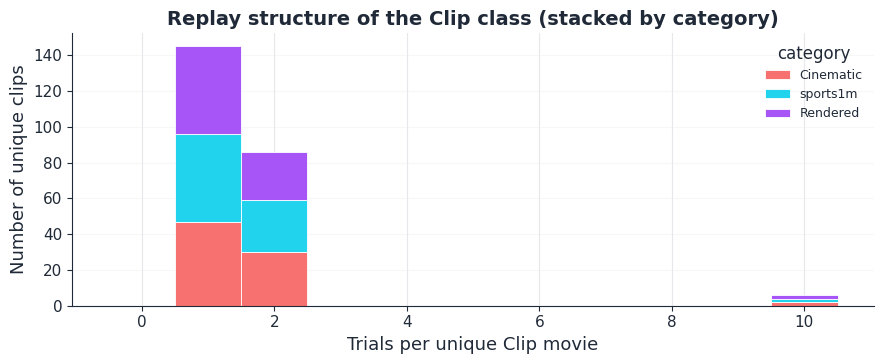

In [9]:
fig, ax = plt.subplots(figsize=(9, 3.8))
o4.plot_trial_count_histogram(inventory, ax=ax)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "1_1_trial_count_histogram.png", dpi=150)
plt.show()

### 1.2 Category exemplars

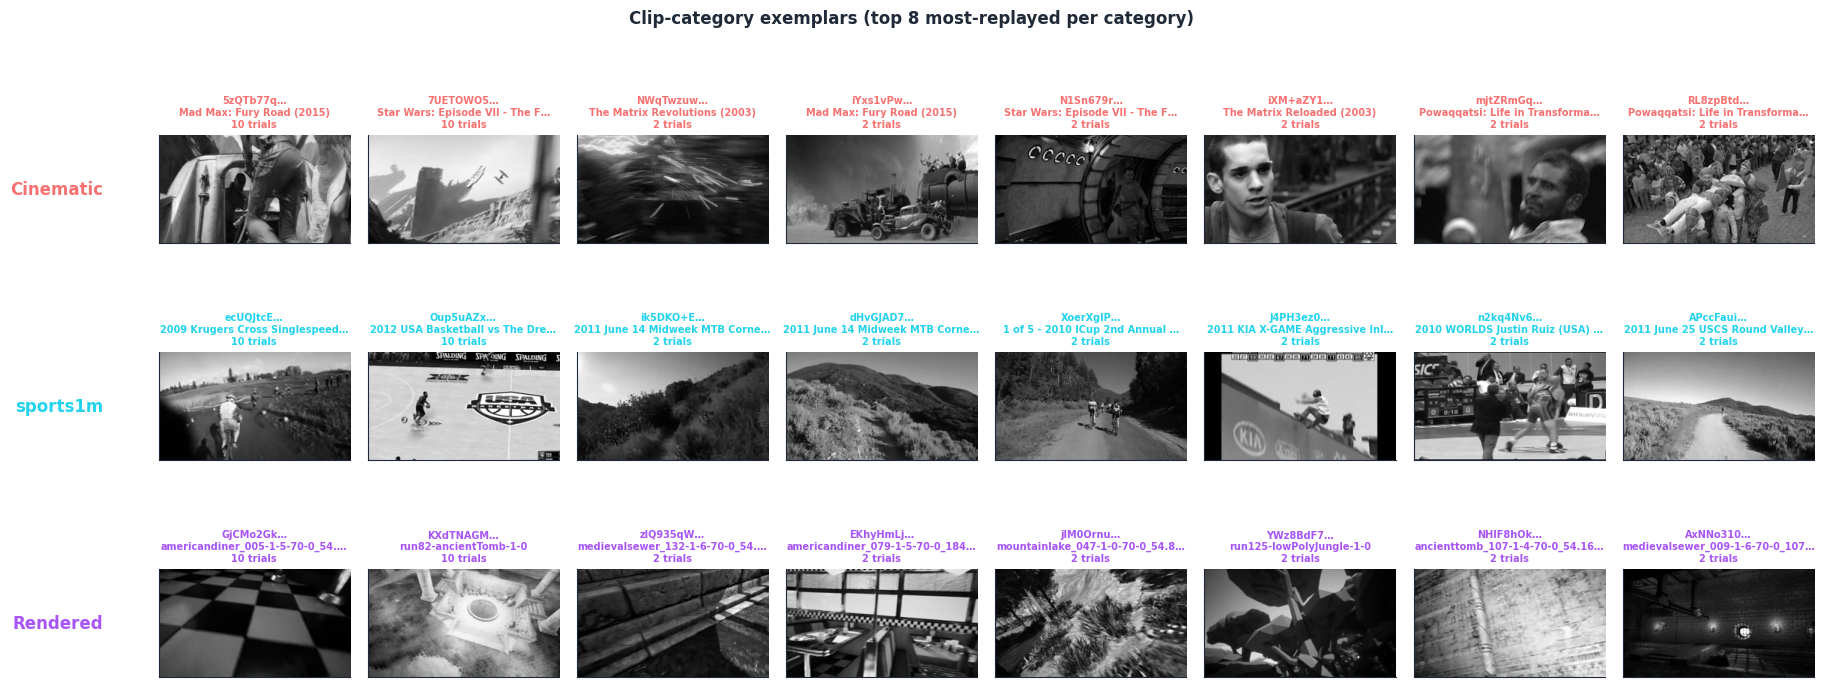

In [10]:
fig = o4.plot_category_exemplars(reader, inventory, n_per_category=N_PER_CATEGORY_THUMBNAILS)
fig.savefig(FIGURES_DIR / "1_2_category_exemplars.png", dpi=150, bbox_inches="tight")
plt.show()

### 1.3 Frame-strip preview (within-clip evolution)

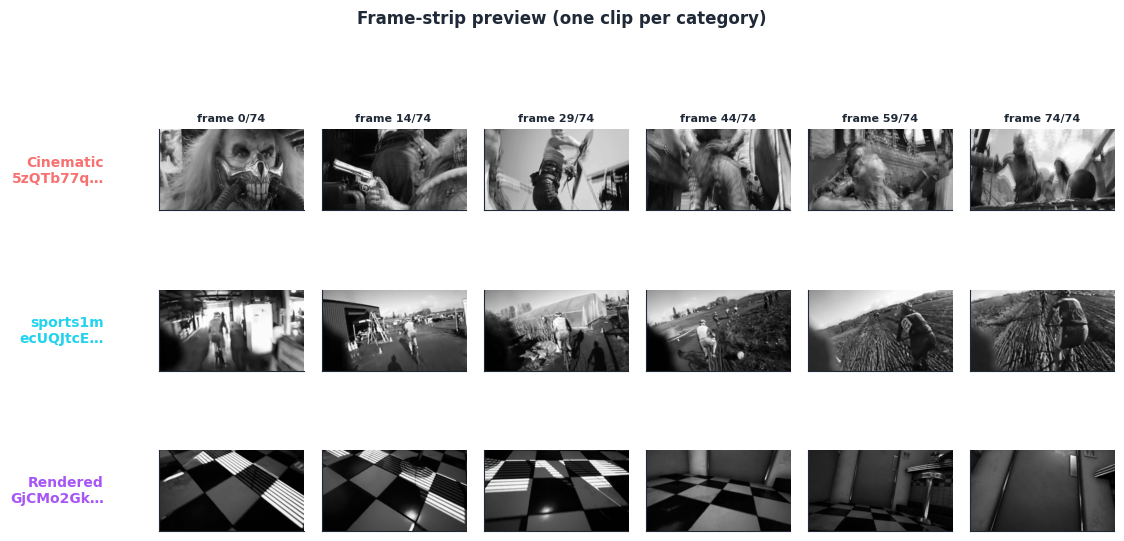

In [11]:
fig = o4.plot_frame_strip_per_category(reader, inventory, n_frames=N_FRAMES_PER_STRIP)
fig.savefig(FIGURES_DIR / "1_3_frame_strips.png", dpi=150, bbox_inches="tight")
plt.show()

### 1.4 Big-picture catalog

One mid-frame per unique Clip movie, sorted by category (Cinematic block, sports1m block, Rendered block). Panel titles colored by category. Saved at `dpi=100` to keep the file size manageable.

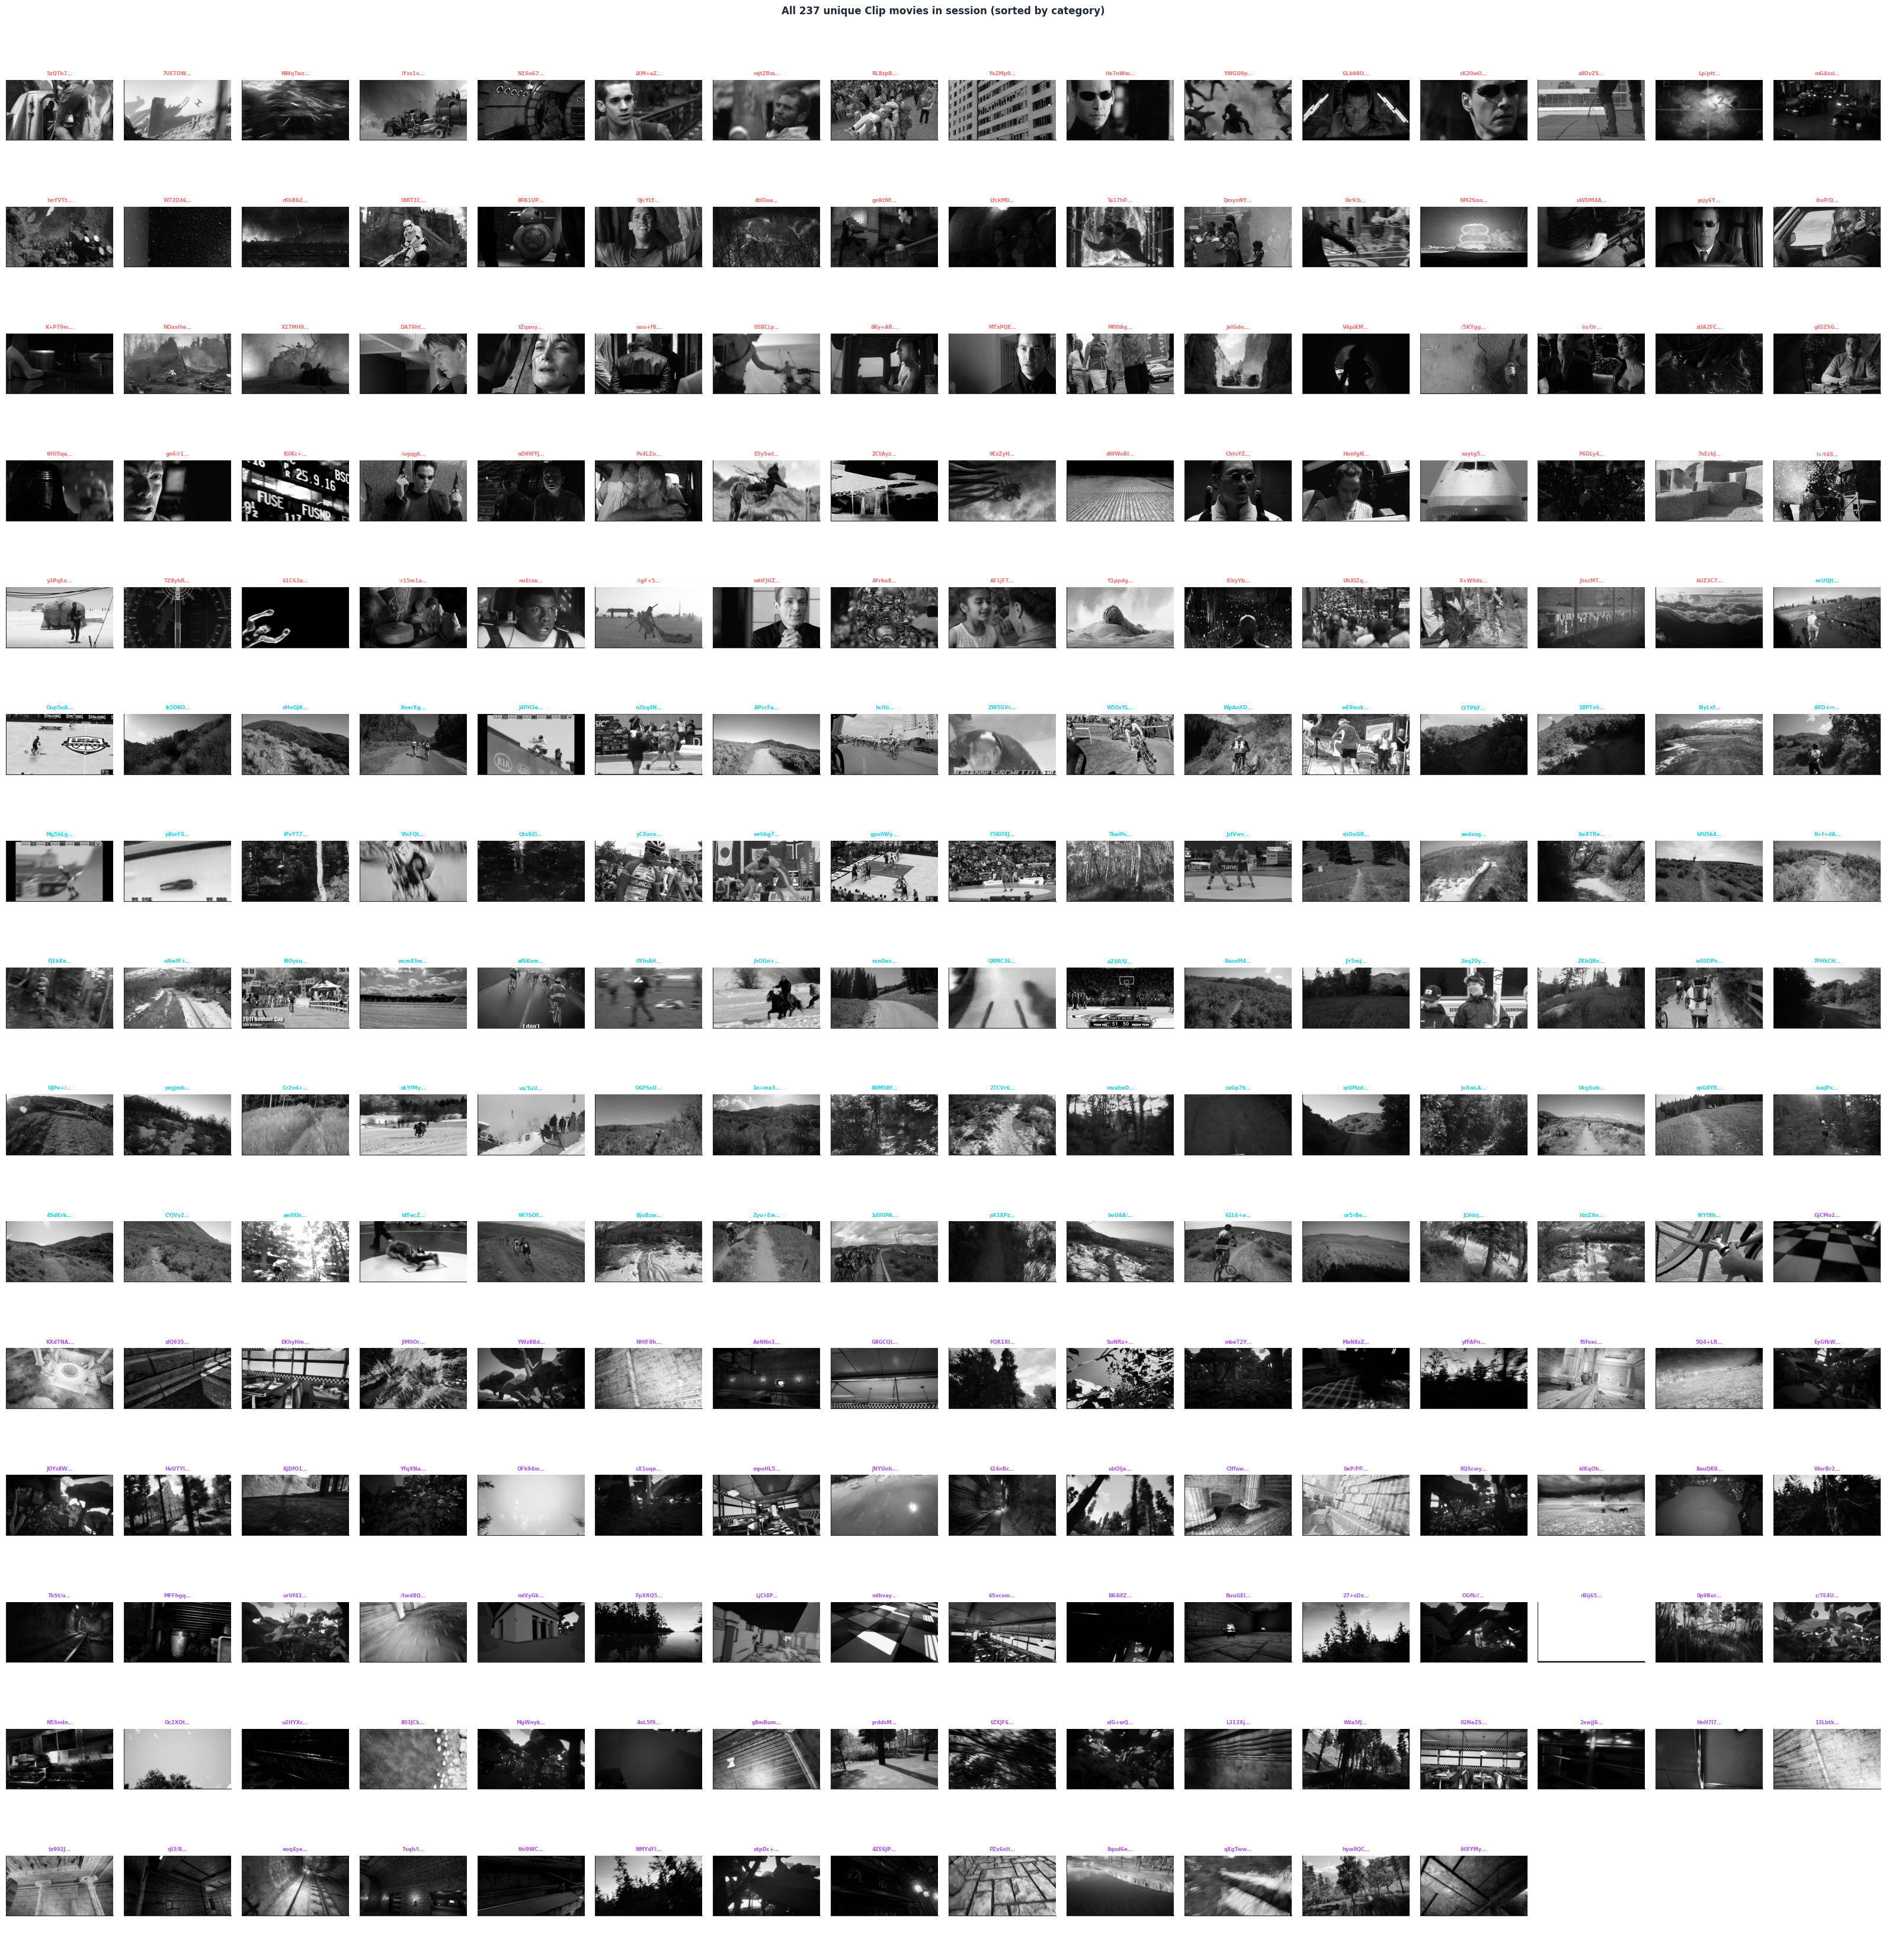

In [12]:
fig = o4.plot_full_thumbnail_grid(reader, inventory, ncols=THUMBNAIL_GRID_NCOLS)
if fig is None:
    print(f"Inventory has > 400 unique clips; skipped the big-picture grid.")
else:
    fig.savefig(FIGURES_DIR / "1_4_full_thumbnail_grid.png", dpi=100, bbox_inches="tight")
    plt.show()

### Part 1: comments

**Dataset retention is high.** 453/464 trials (≈97.6%) survive the treadmill running-QC threshold. Of those clean trials, 377 (≈83%) belong to the Clip class, a comfortably large pool for the within-Clip analysis.

**The three categories are nearly perfectly balanced**, both in trial count (127 / 127 / 123) and in unique-movie count (79 / 80 / 78). This is convenient: pair-wise category contrasts in Part 2 are not confounded by class-imbalance, and no rebalancing trick is needed. (Still *neuron* counts across cortical areas are very unbalanced, V1 has ≈13× more neurons than AL, which is a separate issue, addressed by the equal-population control in Part 2.5.)

**Replay structure.** The 377 clip trials split cleanly into three regimes:

| n_replays | n_unique_clips | % of clips | total trials | % of trials |
|---|---|---|---|---|
| 1× | 145 | 61.2% | 145 | 38.5% |
| 2× | 86 | 36.3% | 172 | 45.6% |
| 10× | 6 | 2.5% | 60 | 15.9% |

Two things stand out. First, the bulk of the *clip inventory* (97.5%) is shown only once or twice, within-category averaging is therefore dominated by content variance across many different movies rather than by repetition of the same clip, which is exactly what we want for a category-level comparison. Second, although the 10× "oracle" clips are only 2.5% of the inventory, they contribute ≈16% of the trials. That over-representation matters: a handful of specific oracle clips will weigh disproportionately in the per-category trial averages of Part 2, so any per-category effect could in principle be carried by those few clips.

**What each category actually contains.**
- **Cinematic**: excerpts from feature films (Mad Max: Fury Road, Star Wars: TFA, The Matrix Revolutions, …). Real-world footage with real actors and real cinematography.
- **sports1m**: clips from the Sports-1M YouTube dataset: team sports, cycling, athletics, etc. Naturalistic but content-biased toward fast object/agent motion and characteristic stadium/court scene structure.
- **Rendered**: clips produced by a 3D game/simulation engine (filenames such as `medievalsewer_…`, `mountainlake_…`, `swamp_…`, `run157-mountainLake-…`). They preserve naturalistic optic flow and dynamic scenes but are entirely synthetic, no real cameras, no real actors, with photometry and texture statistics that depart from natural images.

**Why this is the right setup for Part 2.** The three categories differ in content (feature films, amateur sport footage, rendered 3-D scenes) and, inevitably, in low-level statistics; a neural separation between them is therefore a difference between three sets of movies, not evidence for content-category coding as such (see the caveat below). The per-category sample is ~125 trials, but from only ~80 unique clips per
category (8 films for Cinematic); the shuffle null in Part 2 therefore
permutes labels between clips, not between trials. 

**The main caveat to keep in mind.** The three categories almost certainly differ in basic image properties, average brightness, contrast, amount of motion, colour palette. So if neural trajectories separate the categories, it might just reflect those low-level differences rather than the brain actually coding for "cinema vs sports vs synthetic". This experiment can't distinguish the two, and that limitation should be acknowledged in the final takeaways.

## Part 2: Per-category trajectories

Mirrors experiment 2 part-for-part with the labels swapped from `Clip / Monet2 / Trippy` to `Cinematic / sports1m / Rendered`. Pipeline is reused from `experiment2_utils`; the palette and stim_order kwargs change, and the shuffle null, split-half distance and subsampling control are run with `groups=` set to the clip hash.

### 2.0 Build trajectories

Per-category, per-area trial-averaged trajectories with the time axis preserved. Uses the experiment 1 preprocessing (detrend → z-score) and the experiment 2 trajectory builder.

In [13]:
print("loading + preprocessing responses...")
responses, trial_boundaries, _ = microns_eda.load_session_responses(
    reader, DATADIR, SESSION,
)
responses_pp = pca_utils.preprocess_responses(responses, apply_log=False)
print(f"  preprocessed shape = {responses_pp.shape}")

brain_areas_str = np.array([
    a.decode("utf-8", "replace") if isinstance(a, bytes) else str(a)
    for a in meta["brain_areas"]
], dtype=object)

trajectories = traj_utils.build_stim_trajectories(
    responses_pp, trial_boundaries,
    clip_trial_indices,
    brain_areas_str,
    clip_category_labels,
    n_frames=N_FRAMES_TRUNCATE,
)

for area, per_cat in trajectories.items():
    shapes = {c: t.shape for c, t in per_cat.items()}
    print(f"  {area}: {shapes}")

# Sanity asserts.
for area in ["V1", "AL", "LM", "RL"]:
    assert area in trajectories
    for cat in o4.CATEGORY_ORDER:
        assert cat in trajectories[area], f"no trajectory for {area}/{cat}"
        t = trajectories[area][cat]
        assert t.shape[0] == N_FRAMES_TRUNCATE, f"frame count mismatch {area}/{cat}: {t.shape}"
        assert not np.any(np.isnan(t)), f"NaN in {area}/{cat}"

traj_path = RESULTS_DIR / "trajectories.npz"
traj_utils.save_trajectories(trajectories, traj_path)
print(f"\nwrote {traj_path}")

loading + preprocessing responses...
  preprocessed shape = (8194, 37840)
  AL: {'Cinematic': (75, 414), 'Rendered': (75, 414), 'sports1m': (75, 414)}
  LM: {'Cinematic': (75, 1262), 'Rendered': (75, 1262), 'sports1m': (75, 1262)}
  RL: {'Cinematic': (75, 1033), 'Rendered': (75, 1033), 'sports1m': (75, 1033)}
  V1: {'Cinematic': (75, 5485), 'Rendered': (75, 5485), 'sports1m': (75, 5485)}

wrote results/exp3_clip_categories/7_5/trajectories.npz


### 2.1 Fit per-area PCA on stacked-category matrix

Stack the three trajectories vertically per area (3 × 75 = 225 frames × n_neurons), then fit a per-area PCA. PC1 typically captures stimulus-common temporal dynamics (rise at onset, settle later); the category-identity signal lives in PC2-PC3 in the visualisations. Reuses the experiment 2 helper unchanged.

In [14]:
pca_per_area = traj_utils.fit_trajectory_pca(
    trajectories, n_components=N_COMPONENTS, random_state=RANDOM_SEED,
)
for area in ["V1", "AL", "LM", "RL"]:
    cum = np.cumsum(pca_per_area[area]["pca"].explained_variance_ratio_)
    print(f"{area:5s} top-3 cum.var = {cum[2]:.3f},  top-10 cum.var = {cum[9]:.3f}")

V1    top-3 cum.var = 0.196,  top-10 cum.var = 0.308
AL    top-3 cum.var = 0.307,  top-10 cum.var = 0.418
LM    top-3 cum.var = 0.230,  top-10 cum.var = 0.345
RL    top-3 cum.var = 0.221,  top-10 cum.var = 0.332


### 2.2 V1 deep-dive

2-D and 3-D scatters of the trajectories, full-feature and top-3-PC distance time courses, shuffle null (n=100) with labels permuted between *clips* (repeats of one clip are not independent trials), bias-corrected split-half distances, and onset latency per pair (first frame at which the observed distance exceeds the null-of-the-max 95th percentile; none if the pair is not significant).

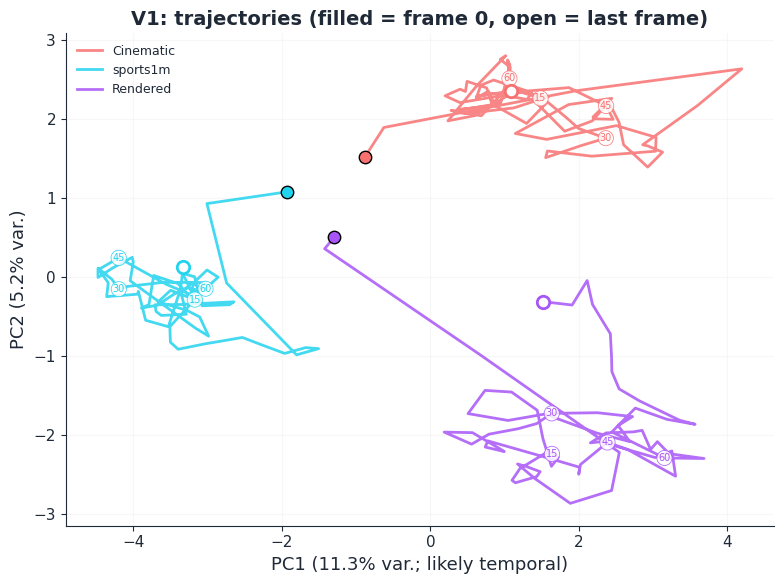

saved 3D Plotly to 2_2_v1_trajectory_3d.html


In [15]:
v1_pca = pca_per_area["V1"]["pca"]
v1_stim_pcs = pca_per_area["V1"]["stim_pcs"]

# 2-D scatter.
fig, ax = plt.subplots(figsize=(8, 6))
traj_utils.plot_trajectory_2d(
    v1_stim_pcs, "V1", v1_pca,
    palette=o4.CATEGORY_COLORS, stim_order=o4.CATEGORY_ORDER,
    ax=ax,
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "2_2_v1_trajectory_2d.png", dpi=150)
plt.show()

# 3-D Plotly scatter.
fig3d = traj_utils.plot_trajectory_3d_plotly(
    v1_stim_pcs, "V1", v1_pca,
    palette=o4.CATEGORY_COLORS, stim_order=o4.CATEGORY_ORDER,
)
fig3d.write_html(str(FIGURES_DIR / "2_2_v1_trajectory_3d.html"))
print("saved 3D Plotly to 2_2_v1_trajectory_3d.html")

In [16]:
# Build the V1 trial × time × neuron tensor (used by bootstrap + null).
# Same helper experiment 2's notebook defines locally: kept inline here so this
# notebook stays self-contained and experiment2_utils.py is unchanged.
def _build_trial_tensor(responses_pp, trial_boundaries, trial_indices, cols, n_frames):
    out = np.empty((len(trial_indices), n_frames, len(cols)), dtype=np.float64)
    for out_idx, t_idx in enumerate(trial_indices):
        start = int(trial_boundaries[t_idx])
        if start + n_frames > int(trial_boundaries[t_idx + 1]):
            raise ValueError(f"trial {t_idx} is shorter than n_frames={n_frames}")
        out[out_idx] = responses_pp[cols, start:start + n_frames].T
    return out

v1_tensor_cols = np.where(brain_areas_str == "V1")[0]
v1_tensor = _build_trial_tensor(
    responses_pp, trial_boundaries, clip_trial_indices, v1_tensor_cols,
    N_FRAMES_TRUNCATE,
)
print(f"V1 tensor shape: {v1_tensor.shape}")

v1_d_full = traj_utils.pairwise_trajectory_distance(
    trajectories["V1"], metric="full",
)
v1_d_top3 = traj_utils.pairwise_trajectory_distance(
    trajectories["V1"], metric="top_pcs",
    pca=v1_pca, n_pcs=N_PCS_FOR_DISTANCE,
)

# Exchangeable unit = the clip, not the trial: 377 Clip trials come from 237
# unique clips (6 shown 10x, 86 shown 2x). Repeats of one clip give correlated
# responses, so the null permutes category labels between clips, the
# bootstrap resamples clips, and the split-half distance splits by clip.
# (A trial-level permutation on such data returns p = 0.01 on every pair even
# when the categories are assigned at random.)
GROUPS = clip_hashes_per_trial

print(f"bias-corrected (split-half) distances (n_splits={N_CV_SPLITS})...")
v1_cv_full = traj_utils.crossvalidated_distance(
    v1_tensor, clip_category_labels, metric="full",
    n_splits=N_CV_SPLITS, seed=RANDOM_SEED + 5, groups=GROUPS,
)
v1_cv_top3 = traj_utils.crossvalidated_distance(
    v1_tensor, clip_category_labels, metric="top_pcs",
    pca=v1_pca, n_pcs=N_PCS_FOR_DISTANCE,
    n_splits=N_CV_SPLITS, seed=RANDOM_SEED + 6, groups=GROUPS,
)
print(f"shuffle null (n={N_SHUFFLES}, labels permuted between clips)...")
v1_null_full = traj_utils.shuffle_null_max_distance(
    v1_tensor, clip_category_labels, metric="full",
    n_shuffles=N_SHUFFLES, seed=RANDOM_SEED + 3, groups=GROUPS,
)
v1_null_top3 = traj_utils.shuffle_null_max_distance(
    v1_tensor, clip_category_labels, metric="top_pcs",
    pca=v1_pca, n_pcs=N_PCS_FOR_DISTANCE,
    n_shuffles=N_SHUFFLES, seed=RANDOM_SEED + 4, groups=GROUPS,
)

V1 tensor shape: (377, 75, 5485)
bias-corrected (split-half) distances (n_splits=20)...
shuffle null (n=1000, labels permuted between clips)...


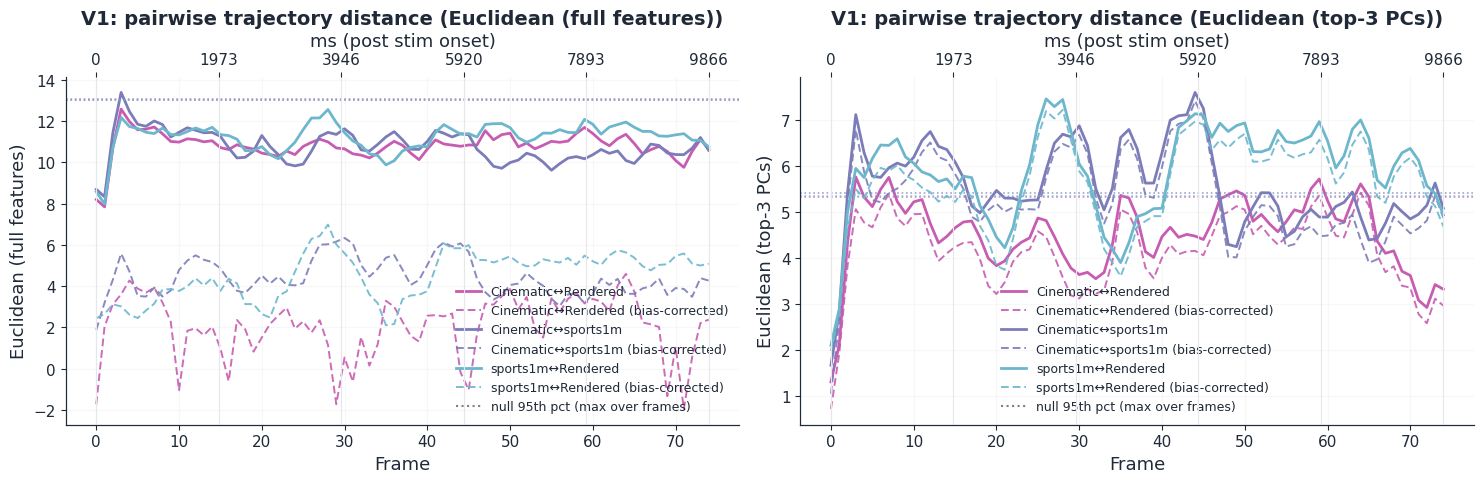

In [17]:
# Two-panel V1 figure: full features + top-3 PC.
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
traj_utils.plot_pairwise_distance_time_course(
    v1_d_full, None, "V1", "Euclidean (full features)",
    null_p95={p: float(np.percentile(v1_null_full[p], 95)) for p in v1_null_full},
    cv_distances=v1_cv_full,
    pair_palette=o4.category_pair_palette(),
    pair_labels=o4.category_pair_labels(),
    ax=axes[0],
)
traj_utils.plot_pairwise_distance_time_course(
    v1_d_top3, None, "V1", "Euclidean (top-3 PCs)",
    null_p95={p: float(np.percentile(v1_null_top3[p], 95)) for p in v1_null_top3},
    cv_distances=v1_cv_top3,
    pair_palette=o4.category_pair_palette(),
    pair_labels=o4.category_pair_labels(),
    ax=axes[1],
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "2_2_v1_distances.png", dpi=150)
plt.show()

### Interpretation

**The variance numbers are modest, and that's expected.** The top 3 PCs only
capture ~20–30% of the response variance per area (V1 19.6%, LM 23.0%,
RL 22.1%, AL 30.7%). Movie clips are rich, dynamic stimuli that engage many
response patterns at once, so the population code is genuinely
high-dimensional, no handful of components is going to swallow most of it.
AL's higher number isn't because AL is "better"; it just has 414 neurons vs
V1's ~5500. A smaller population has fewer independent directions, so each PC
eats a bigger slice of the total. The numbers are consistent with what the
data is, not a sign that PCA is failing.

**The V1 2D scatter shows something real at the eye level.** All three
trajectories start near each other around the filled circles (frame 0, just
after stimulus onset). Within ~15 frames they fan out into three distinct
regions of the PC1–PC2 plane and stay there, Cinematic in the upper right,
sports1m on the left, Rendered in the lower right. The time-point labels
(15, 30, 45, 60) bunch up on top of each other *inside* each category's
region, which means after the initial onset the trajectory loops around
inside a category-specific zone rather than continuing to drift. Each
category's mean trajectory stays within a region. (This PCA is fit on the
three class-mean trajectories themselves, so their separation in this
projection is expected by construction; the test is in 2.3.)

**PC1 looks like a stimulus-onset axis, not a category axis.** Frame 0 sits
at low PC1 for all three categories; later frames spread along PC1. This
indicates that PC1 is mostly the rise-and-settle
response that all clips share. Category identity has to live somewhere else.

**PC2 and PC3 carry the between-category differences in this projection.** Both the 2D plot (PC1 vs PC2) and the 3D plot show the three category-mean trajectories in separate regions, and adding PC3 (3.1% of the variance) separates them further. Small variance
does not mean small information, but note again that the projection was fit
on the class means being compared, so "category identity lives in PC2–3"
is a description of this plot, not a tested claim.

### Pairwise trajectory distance

Each plot has three things layered on it: the **solid line** is the raw
observed distance between two category-mean trajectories at each frame, the
**dashed line** is the split-half bias-corrected distance (the raw distance
carries a `sqrt(N·(1/n_A + 1/n_B))` noise floor), and the **dotted
horizontal line** is the 95th percentile of the shuffle null of the
max-over-frames distance, with category labels permuted between the 237
unique clips (the bar the solid line has to clear, at any frame, to count as
significant; testing every frame against the null of the max keeps the
family-wise error over the 75 frames at 5 %).

Three things to read off the V1 plots:

**Time course.** All three raw curves rise over the first 2–3 frames and
then stay roughly flat for the rest of the 10-second trial.

**In V1 no category pair is significant after correction.** The raw maxima
(12.6–13.4) sit at or just below the clip-level null thresholds
(13.0–13.1): Cinematic↔sports1m p = 0.014, Cinematic↔Rendered p = 0.195,
Rendered↔sports1m p = 0.175 uncorrected, and Holm-adjusted over the 12
area × pair tests 0.098 / 0.699 / 0.699. No onset is reported. The
bias-corrected maxima (6.3, 4.6, 7.0) show how much of the raw distance is
noise floor: about half.

**The top-3-PC plot is not independent evidence.** The PCA was fit on the
three category-mean trajectories, so distances in that subspace are inflated
relative to a label-shuffled null (see experiment 2, Part 5). It is kept as a
visualisation check only.


### 2.3 Repeat on AL, LM, RL


=== AL ===
  trial tensor shape: (377, 75, 414)
  bias-corrected distances (n_splits=20)...
  shuffle null (n=1000, labels permuted between clips)...

=== LM ===
  trial tensor shape: (377, 75, 1262)
  bias-corrected distances (n_splits=20)...
  shuffle null (n=1000, labels permuted between clips)...

=== RL ===
  trial tensor shape: (377, 75, 1033)
  bias-corrected distances (n_splits=20)...
  shuffle null (n=1000, labels permuted between clips)...


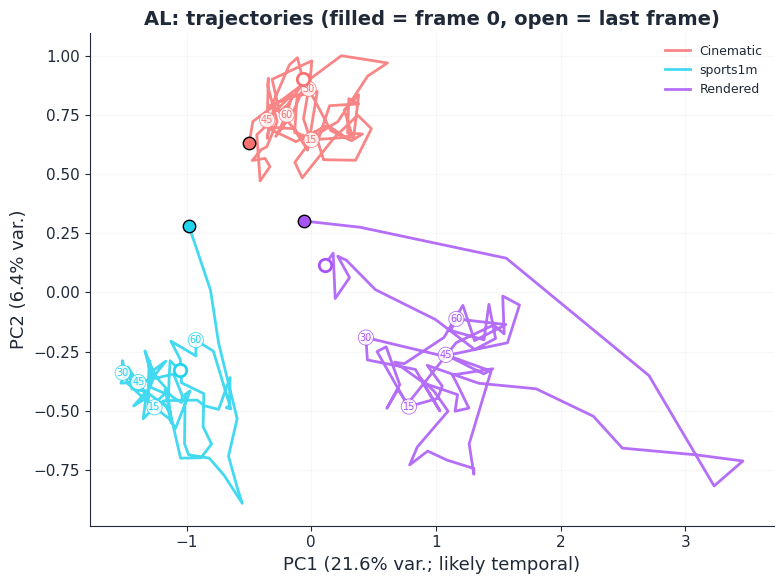

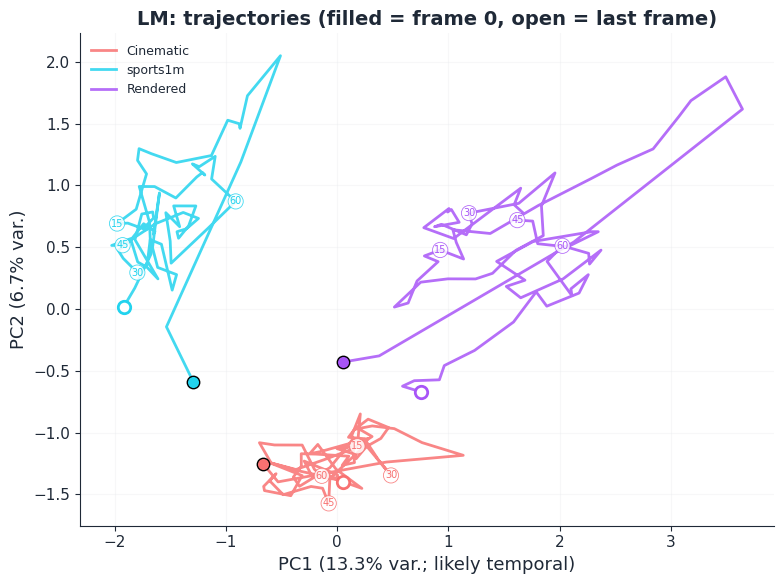

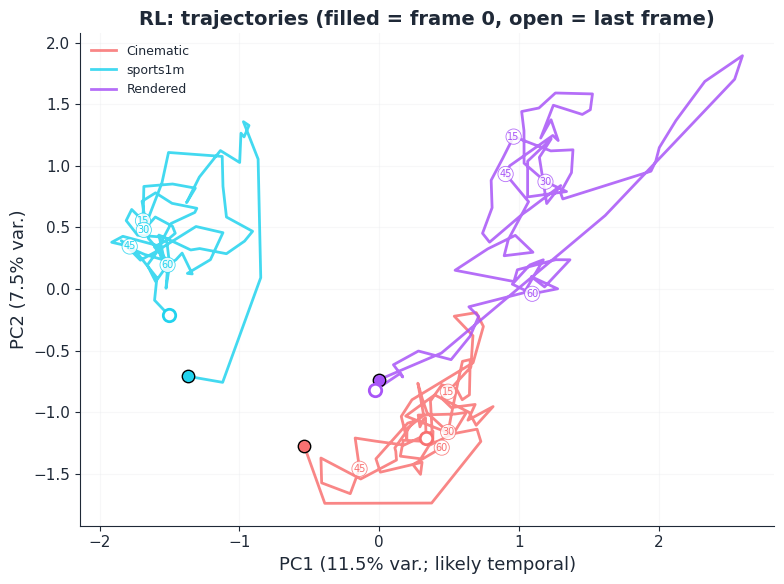

In [18]:
all_area_results = {
    "V1": {
        "tensor": v1_tensor,
        "trajectories": trajectories["V1"],
        "pca": v1_pca,
        "stim_pcs": v1_stim_pcs,
        "distances_full": v1_d_full,
        "distances_top3": v1_d_top3,
        "cv_full": v1_cv_full,
        "cv_top3": v1_cv_top3,
        "null_full": v1_null_full,
        "null_top3": v1_null_top3,
        "n_neurons": v1_tensor.shape[2],
    },
}

for area in ["AL", "LM", "RL"]:
    print(f"\n=== {area} ===")
    cols = np.where(brain_areas_str == area)[0]
    tensor = _build_trial_tensor(
        responses_pp, trial_boundaries, clip_trial_indices, cols,
        N_FRAMES_TRUNCATE,
    )
    print(f"  trial tensor shape: {tensor.shape}")
    pca_a = pca_per_area[area]['pca']
    stim_pcs_a = pca_per_area[area]['stim_pcs']
    d_full = traj_utils.pairwise_trajectory_distance(
        trajectories[area], metric="full",
    )
    d_top3 = traj_utils.pairwise_trajectory_distance(
        trajectories[area], metric="top_pcs",
        pca=pca_a, n_pcs=N_PCS_FOR_DISTANCE,
    )
    print(f"  bias-corrected distances (n_splits={N_CV_SPLITS})...")
    cv_full = traj_utils.crossvalidated_distance(
        tensor, clip_category_labels, metric="full",
        n_splits=N_CV_SPLITS, seed=RANDOM_SEED + 50 + ord(area[0]), groups=GROUPS,
    )
    cv_top3 = traj_utils.crossvalidated_distance(
        tensor, clip_category_labels, metric="top_pcs",
        pca=pca_a, n_pcs=N_PCS_FOR_DISTANCE,
        n_splits=N_CV_SPLITS, seed=RANDOM_SEED + 60 + ord(area[0]), groups=GROUPS,
    )
    print(f"  shuffle null (n={N_SHUFFLES}, labels permuted between clips)...")
    null_full = traj_utils.shuffle_null_max_distance(
        tensor, clip_category_labels, metric="full",
        n_shuffles=N_SHUFFLES, seed=RANDOM_SEED + 30 + ord(area[0]), groups=GROUPS,
    )
    null_top3 = traj_utils.shuffle_null_max_distance(
        tensor, clip_category_labels, metric="top_pcs",
        pca=pca_a, n_pcs=N_PCS_FOR_DISTANCE,
        n_shuffles=N_SHUFFLES, seed=RANDOM_SEED + 40 + ord(area[0]), groups=GROUPS,
    )
    all_area_results[area] = {
        "tensor": tensor,
        "trajectories": trajectories[area],
        "pca": pca_a,
        "stim_pcs": stim_pcs_a,
        "distances_full": d_full,
        "distances_top3": d_top3,
        "cv_full": cv_full,
        "cv_top3": cv_top3,
        "null_full": null_full,
        "null_top3": null_top3,
        "n_neurons": tensor.shape[2],
    }

# Per-area scatters.
for area in ["AL", "LM", "RL"]:
    res = all_area_results[area]
    fig, ax = plt.subplots(figsize=(8, 6))
    traj_utils.plot_trajectory_2d(
        res['stim_pcs'], area, res['pca'],
        palette=o4.CATEGORY_COLORS, stim_order=o4.CATEGORY_ORDER,
        ax=ax,
    )
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / f"2_3_{area.lower()}_trajectory_2d.png", dpi=150)
    plt.show()
    fig3d = traj_utils.plot_trajectory_3d_plotly(
        res['stim_pcs'], area, res['pca'],
        palette=o4.CATEGORY_COLORS, stim_order=o4.CATEGORY_ORDER,
    )
    fig3d.write_html(str(FIGURES_DIR / f"2_3_{area.lower()}_trajectory_3d.html"))

### 2.3: what the higher-area plots show

**The three categories separate cleanly in all three higher areas.** As in V1,
the trajectories all start near each other (the filled circles, frame 0) and
then fan out into three distinct regions of the PC1–PC2 plane, where they
loop around for the rest of the trial. So the "rise, then plateau" shape of the raw curves from V1 is also seen in
the other three recorded areas (four areas of one session; nothing here
tests a hierarchy).

**AL has the cleanest visual separation, despite being the smallest
population.** AL has only 414 neurons (vs 1262 in LM, 1033 in RL, 5485 in
V1), but the three category clusters in its 2D plot are the most clearly
detached, Cinematic up, sports1m down-left, Rendered down-right with a
long tail. PC1 alone captures 21.6% of the variance in AL, roughly twice
what it captures in V1 (11.3%) or RL (11.5%). Part of this is the
small-population effect we already saw in 2.1: with fewer neurons there are
fewer independent directions, so each PC eats a bigger slice. But it's also
consistent with AL having a more compact, category-aligned representation
per neuron.

**LM and RL look almost like rotated copies of each other.** Both arrange
the three categories in the same Y-shape geometry, Cinematic at the bottom,
sports1m in the upper-left, Rendered in the upper-right, and both have
similar variance numbers (top-3 cum.var: LM 23.0%, RL 22.1%). They look
like they're doing similar things to the stimulus.

### 2.4 Cross-area headline (all three pairs)

Two figures (one per metric, full and top-3 PC), each laid out as 1×3 panels, one panel per category pair (Cinematic↔sports1m, Cinematic↔Rendered, sports1m↔Rendered). Each panel shows that pair's distance time course across the four cortical areas, with the bias-corrected curve dashed and
each area's null threshold dotted.

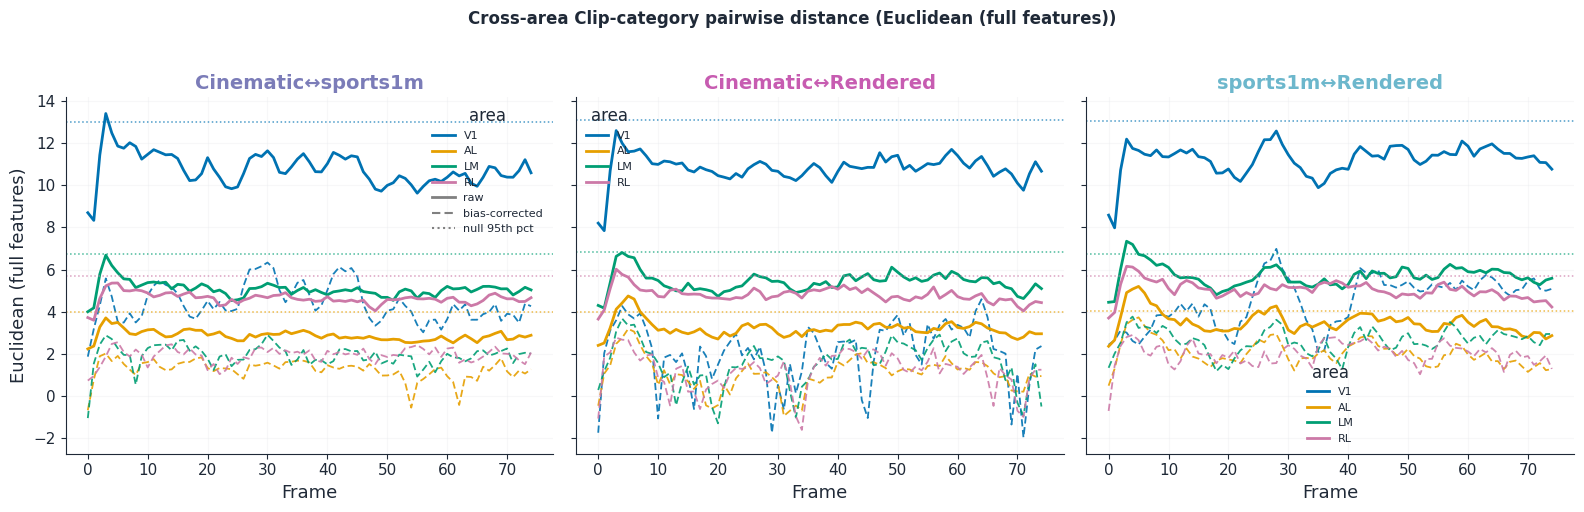

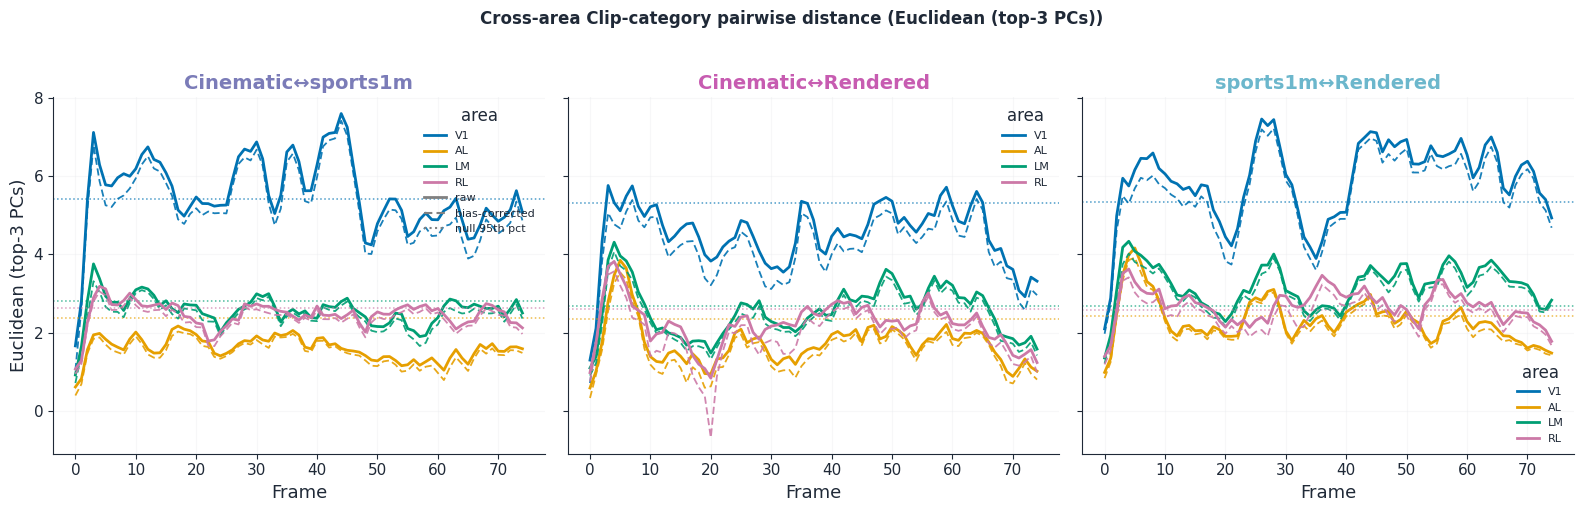

In [19]:
# Headline: full-feature metric.
fig_full = o4.plot_cross_area_three_pairs(
    all_area_results,
    metric_label="Euclidean (full features)",
    metric_key="distances_full",
    cv_key="cv_full", null_key="null_full",
)
fig_full.savefig(FIGURES_DIR / "2_4_cross_area_three_pairs_full.png",
                 dpi=150, bbox_inches="tight")
plt.show()

# Visualisation-aligned check: top-3 PC metric.
fig_top3 = o4.plot_cross_area_three_pairs(
    all_area_results,
    metric_label="Euclidean (top-3 PCs)",
    metric_key="distances_top3",
    cv_key="cv_top3", null_key="null_top3",
)
fig_top3.savefig(FIGURES_DIR / "2_4_cross_area_three_pairs_top3.png",
                 dpi=150, bbox_inches="tight")
plt.show()

In [20]:
# Per-session metrics CSV (matches experiment 2's schema).
def _build_metric_rows(results, analysis_label):
    """One row per (area, metric, pair).

    Columns: ``max_distance_observed`` (raw, noise-inflated), ``max_distance_cv``
    (split-half bias-corrected, comparable across pairs and areas),
    ``max_distance_null_p95`` and ``empirical_p_value`` (observed max vs the
    shuffle null of the max), ``onset_frame`` / ``onset_ms`` (first frame at
    which the *observed* curve exceeds the null-of-the-max 95th percentile;
    ``None`` whenever the pair is not significant after Holm), ``p_holm`` and
    ``n_tests`` (Holm over the 12 tests of one metric).
    """
    rows = []
    for area, res in results.items():
        for metric_label, dist_key, cv_key, null_key in [
            ("full", "distances_full", "cv_full", "null_full"),
            ("top3_pc", "distances_top3", "cv_top3", "null_top3"),
        ]:
            for pair in res[dist_key]:
                d = res[dist_key][pair]
                cv = res[cv_key][pair]
                null = res[null_key][pair]
                obs_max = float(d.max())
                p95 = float(np.percentile(null, 95))
                p = float((1 + (null >= obs_max).sum()) / (1 + len(null)))
                lat = traj_utils.compute_onset_latency(d, null, alpha=0.05)
                rows.append({
                    "area": area,
                    "n_neurons": res["n_neurons"],
                    "pair": "/".join(sorted(pair)),
                    "metric": metric_label,
                    "max_distance_observed": obs_max,
                    "max_distance_cv": float(cv.max()),
                    "max_distance_null_p95": p95,
                    "empirical_p_value": p,
                    "onset_frame": lat,
                    "onset_ms": frame_to_ms(lat) if lat is not None else None,
                    "analysis": analysis_label,
                })
    # Holm over the family of one metric (4 areas x 3 pairs = 12 tests).
    # Onsets are reported only for pairs that survive the correction.
    df = pd.DataFrame(rows)
    for metric_label in ("full", "top3_pc"):
        fam = df["metric"] == metric_label
        df.loc[fam, "p_holm"] = pca_utils.holm_adjust(df.loc[fam, "empirical_p_value"])
        df.loc[fam, "n_tests"] = int(fam.sum())
    not_sig = df["p_holm"] >= 0.05
    df.loc[not_sig, ["onset_frame", "onset_ms"]] = None
    return df.to_dict("records")

results_df = pd.DataFrame(_build_metric_rows(all_area_results, "all_neurons"))
csv_path = RESULTS_DIR / "trajectory_metrics.csv"
results_df.to_csv(csv_path, index=False)
print(f"wrote {csv_path}  ({len(results_df)} rows)")
results_df

wrote results/exp3_clip_categories/7_5/trajectory_metrics.csv  (24 rows)


,area,n_neurons,pair,metric,max_distance_observed,max_distance_cv,max_distance_null_p95,empirical_p_value,onset_frame,onset_ms,analysis,p_holm,n_tests
0,V1,5485,Cinematic/Rendered,full,12.579643,4.591842,13.082876,0.194805,NaN,NaN,all_neurons,0.699301,12.0
1,V1,5485,Cinematic/sports1m,full,13.387419,6.330871,13.006504,0.013986,NaN,NaN,all_neurons,0.097902,12.0
2,V1,5485,Rendered/sports1m,full,12.559754,6.979207,13.023444,0.174825,NaN,NaN,all_neurons,0.699301,12.0
3,V1,5485,Cinematic/Rendered,top3_pc,5.755661,5.411042,5.312346,0.021978,3.0,400.000000,all_neurons,0.043956,12.0
4,V1,5485,Cinematic/sports1m,top3_pc,7.593792,7.408339,5.411803,0.000999,3.0,400.000000,all_neurons,0.011988,12.0
5,V1,5485,Rendered/sports1m,top3_pc,7.453399,7.215398,5.340283,0.000999,3.0,400.000000,all_neurons,0.011988,12.0
6,AL,414,Cinematic/Rendered,full,4.747518,3.191257,3.992673,0.000999,3.0,400.000000,all_neurons,0.011988,12.0
7,AL,414,Cinematic/sports1m,full,3.709728,2.021281,3.981575,0.200799,NaN,NaN,all_neurons,0.699301,12.0
8,AL,414,Rendered/sports1m,full,5.200468,3.734689,4.033854,0.000999,3.0,400.000000,all_neurons,0.011988,12.0
9,AL,414,Cinematic/Rendered,top3_pc,3.846390,3.536147,2.349021,0.000999,3.0,400.000000,all_neurons,0.011988,12.0


### 2.4 Interpretation

This is the same pairwise-distance plot as in 2.2, stretched across four
areas. Each panel shows one category pair; each coloured line is one
cortical area (solid raw, dashed bias-corrected, dotted null threshold).

**The temporal shape is similar everywhere.** All four areas in all three
pairs show a rise over the first 2–3 frames and then a plateau. At 7.5 Hz
(133 ms per frame) no latency difference between areas could be resolved.

**Three of the twelve full-feature tests survive Holm correction, none in
V1.** AL Cinematic↔Rendered (raw maximum 4.75 against a null 95th
percentile of 3.99; p = 0.001, p_holm = 0.012), AL Rendered↔sports1m (5.20
vs 4.03; 0.001 / 0.012) and LM Rendered↔sports1m (7.34 vs 6.72; 0.002 /
0.020); all three first exceed the threshold at frame 3 (400 ms). RL
Cinematic↔Rendered and Rendered↔sports1m are just short (p_holm 0.056 and
0.054); V1's best pair is Cinematic↔sports1m at p_holm 0.098; every other
cell is at 0.34 or above. Cinematic↔sports1m is significant nowhere.

**V1's larger raw distances are its neuron count, not a larger effect.**
V1's raw maxima (~12.6–13.4) exceed AL's (~3.7–5.2) because 5,485 neurons
give any two trajectories, real or shuffled, more room to be apart; V1's
null thresholds are correspondingly higher (~13.0 vs ~4.0). Ratios of
observed to null are not comparable across areas either, because the noise
floor scales with `sqrt(N)`. The cross-area comparison is made at matched
population in 2.5; the all-neurons analysis says only which cells pass
their own null.

**The top-3-PC panels** are significant in 11 of 12 cells but are biased by
construction (PCA fit on the class means being compared) and are not used.


### 2.5 Equal-population control

V1 has ~13× more neurons than AL. Distances scale with population size, so we subsample V1, LM, RL down to AL's neuron count (414), 20 random subsamples each, and check whether the cross-area ranking from Part 2.4 survives population matching.

PCA is refitted per subsample; shuffle nulls are NOT recomputed per subsample
(compute cost), so this part is descriptive. The raw distance at matched
population still carries the `sqrt(414·(1/n_A + 1/n_B))` noise floor;
`max_distance_cv` is the comparable quantity. The cross-area ranking question is answered by comparing the median ± IQR of observed distances across the 20 subsamples.

In [27]:
n_match = all_area_results['AL']['n_neurons']
print(f"n_match = {n_match}")

matched_results = {
    'AL': [{
        'trajectories': all_area_results['AL']['trajectories'],
        'distances_full': all_area_results['AL']['distances_full'],
        'distances_top3_pc': all_area_results['AL']['distances_top3'],
        'distances_cv_full': all_area_results['AL']['cv_full'],
    }],
}
for area in ['V1', 'LM', 'RL']:
    print(f"\n=== {area} (matched, {N_POPULATION_SUBSAMPLES} subsamples) ===")
    matched_results[area] = traj_utils.subsample_population_run_pipeline(
        area_name=area,
        trial_tensor=all_area_results[area]['tensor'],
        labels=clip_category_labels,
        n_match=n_match,
        n_subsamples=N_POPULATION_SUBSAMPLES,
        n_components=N_COMPONENTS,
        seed=RANDOM_SEED + ord(area[0]),
        groups=GROUPS,
        n_cv_splits=N_CV_SPLITS,
    )

n_match = 414

=== V1 (matched, 20 subsamples) ===

=== LM (matched, 20 subsamples) ===

=== RL (matched, 20 subsamples) ===


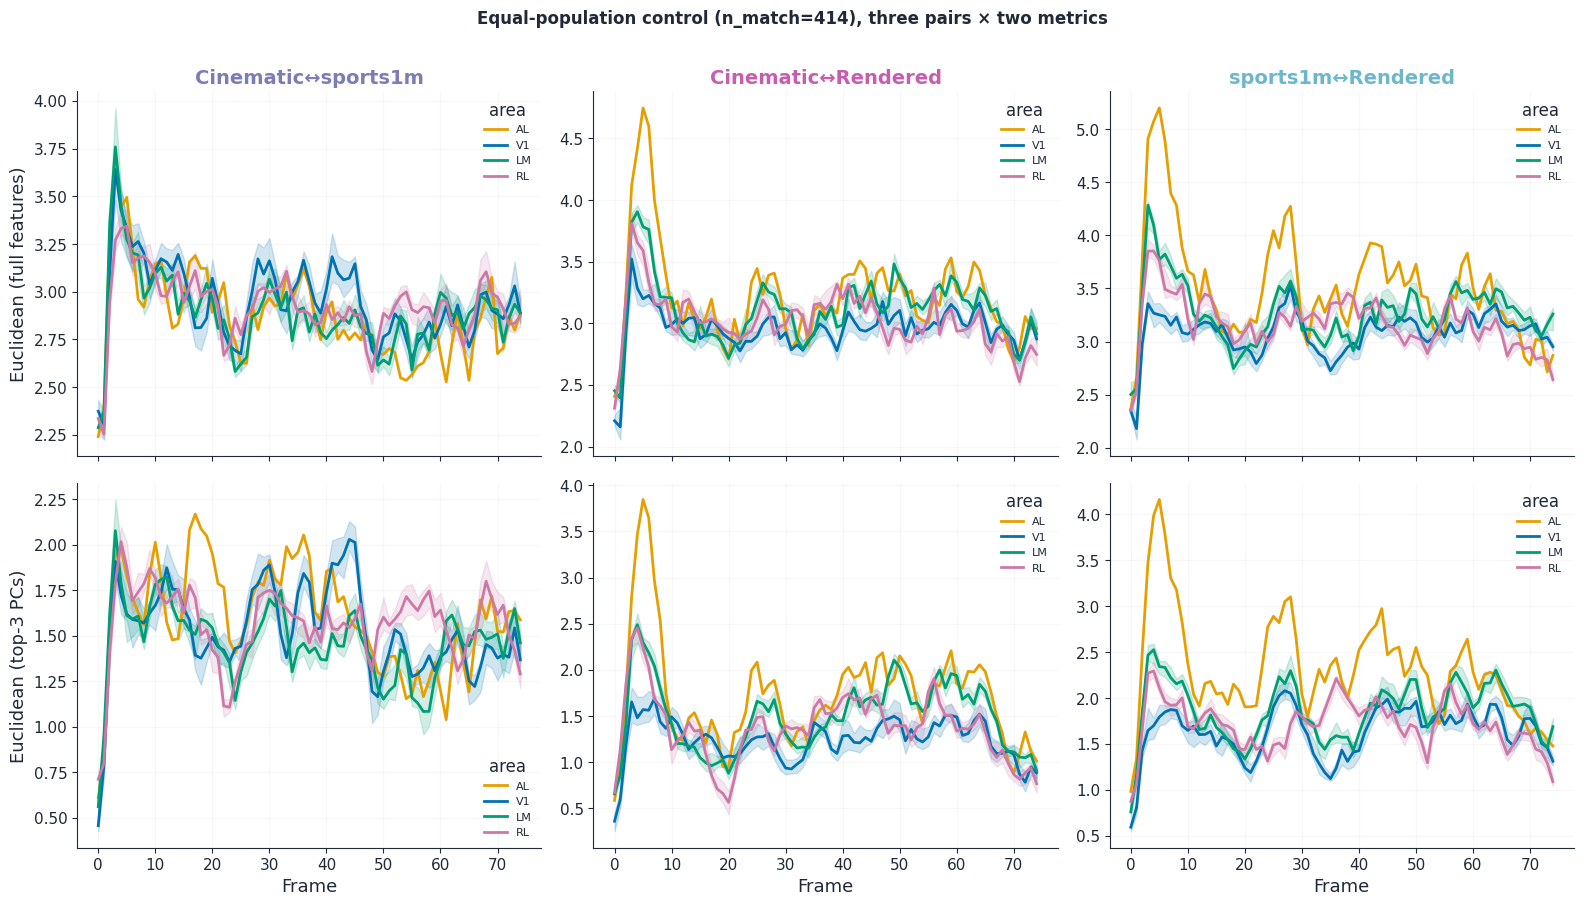

In [22]:
# Plot equal-population distance time courses for the three pairs.
pairs_in_order = [
    frozenset({'Cinematic', 'sports1m'}),
    frozenset({'Cinematic', 'Rendered'}),
    frozenset({'sports1m', 'Rendered'}),
]
pair_palette = o4.category_pair_palette()
pair_labels  = o4.category_pair_labels()
area_palette = {'V1': '#0072B2', 'AL': '#E69F00', 'LM': '#009E73', 'RL': '#CC79A7'}

fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True)
for row_i, (metric_key, metric_label) in enumerate([
    ('distances_full',     'Euclidean (full features)'),
    ('distances_top3_pc',  'Euclidean (top-3 PCs)'),
]):
    for col_j, pair in enumerate(pairs_in_order):
        ax = axes[row_i, col_j]
        for area, sub_list in matched_results.items():
            arr = np.array([d[metric_key][pair] for d in sub_list])
            median = np.median(arr, axis=0)
            x = np.arange(len(median))
            ax.plot(x, median, color=area_palette[area], linewidth=2, label=area)
            if arr.shape[0] > 1:
                q25 = np.quantile(arr, 0.25, axis=0)
                q75 = np.quantile(arr, 0.75, axis=0)
                ax.fill_between(x, q25, q75, color=area_palette[area], alpha=0.18)
        if col_j == 0:
            ax.set_ylabel(metric_label)
        if row_i == 1:
            ax.set_xlabel('Frame')
        if row_i == 0:
            ax.set_title(pair_labels[pair], color=pair_palette[pair])
        ax.legend(loc='best', fontsize=8, title='area')
        ax.grid(True, alpha=0.3)
fig.suptitle(f"Equal-population control (n_match={n_match}), three pairs × two metrics",
             fontsize=12, y=1.005)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "2_5_population_matched.png", dpi=150, bbox_inches="tight")
plt.show()

In [26]:
# Append matched-population rows to the per-session CSV.
matched_rows = []
for area, sub_list in matched_results.items():
    for metric_label, key in [('full', 'distances_full'),
                              ('top3_pc', 'distances_top3_pc')]:
        pair_keys = list(sub_list[0][key].keys())
        for pair in pair_keys:
            arr = np.array([d[key][pair] for d in sub_list])
            obs_max_per_sub = arr.max(axis=1)
            if key == 'distances_full':
                cv_max_per_sub = np.array([d['distances_cv_full'][pair].max() for d in sub_list])
                cv_median = float(np.median(cv_max_per_sub))
            else:
                cv_median = np.nan
            matched_rows.append({
                'area': area,
                'n_neurons': n_match,
                'pair': '/'.join(sorted(pair)),
                'metric': metric_label,
                'max_distance_observed': float(np.median(obs_max_per_sub)),
                'max_distance_cv': cv_median,
                'max_distance_null_p95': np.nan,
                'empirical_p_value': np.nan,
                'onset_frame': None,
                'onset_ms': None,
                'analysis': 'equal_population',
            })
existing = pd.read_csv(csv_path)
existing = existing[existing['analysis'] != 'equal_population']
combined = pd.concat([existing, pd.DataFrame(matched_rows)], ignore_index=True)
combined.to_csv(csv_path, index=False)
print(f"wrote {csv_path}  ({len(combined)} rows total)")

wrote results/exp3_clip_categories/7_5/trajectory_metrics.csv  (48 rows total)


/var/folders/y_/7gd_6b7d7h9b8772krl0vj4m0000gn/T/ipykernel_32461/3972891949.py:30: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined = pd.concat([existing, pd.DataFrame(matched_rows)], ignore_index=True)


### 2.5: comments

This is the same plot as 2.4, but now V1, LM, and RL are randomly subsampled
down to AL's 414 neurons (20 subsamples each, median ± IQR shown). The
question: when every area has the same number of neurons, does AL's
relative advantage from 2.4 survive?

**V1's absolute lead disappears.** With 5485 neurons V1 was at distance ~13;
with 414 neurons it sits in the same ~3 band as LM and RL. So most of V1's
big numbers in 2.4 were geometry, not biology.

**AL's relative advantage holds for two of the three pairs.** In the
Cinematic↔Rendered and sports1m↔Rendered panels, AL (orange) clearly sits
above V1, LM, and RL, most visibly in the early peak and on the top-3-PC
metric. So AL really is more category-discriminating per neuron, not just
small.

**The exception is Cinematic↔sports1m.** Here all four areas overlap
heavily; AL is no longer special. Suggests that sports1m and Cinematic look
similar enough to AL's population that it can't pull them apart any better
than V1 can. The Rendered category, the synthetic one, is where AL
really stands out.

**Bottom line.** V1's huge absolute distances were a population-size artefact, but AL's per-neuron
advantage on the Rendered comparisons is a real effect that survives
population matching.

### 2.6 Cross-session aggregation

Reads `results/exp3_clip_categories/{session}/trajectory_metrics.csv` for every session present and produces a comparison plot. With one session this is a single-session view; with ≥2 sessions, a cross-session comparison.

found 1 session(s), wrote results/exp3_clip_categories/cross_session_summary.csv


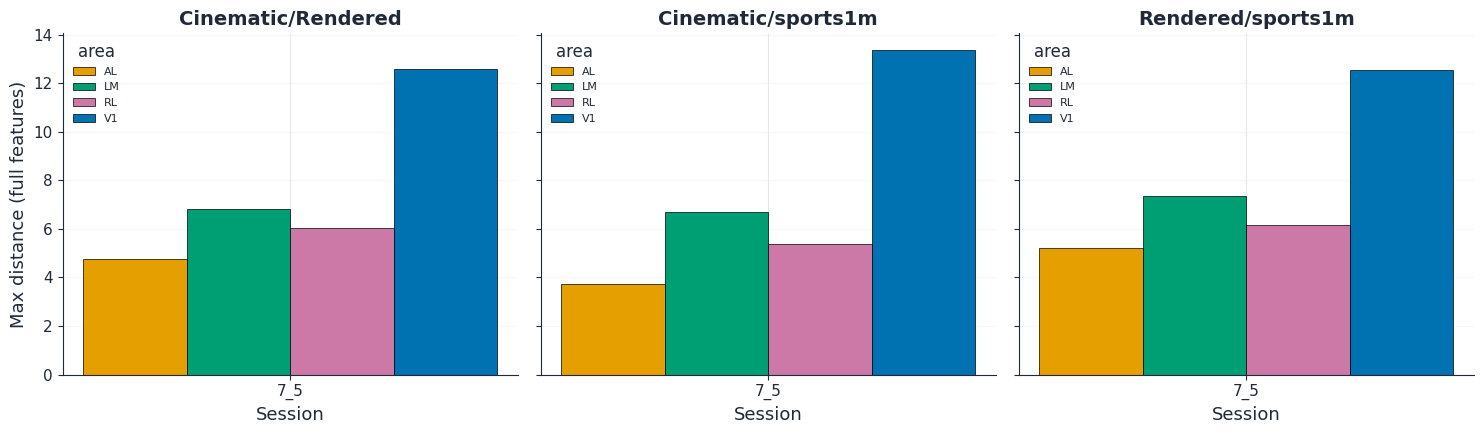

In [29]:
results_root = RESULTS_DIR.parent
session_dfs = []
for session_dir in sorted(results_root.iterdir()):
    if not session_dir.is_dir():
        continue
    csv = session_dir / 'trajectory_metrics.csv'
    if csv.exists():
        df = pd.read_csv(csv)
        df['session'] = session_dir.name
        session_dfs.append(df)

if session_dfs:
    cross_df = pd.concat(session_dfs, ignore_index=True)
    cross_df = cross_df[cross_df['analysis'] == 'all_neurons']
    cross_csv = results_root / 'cross_session_summary.csv'
    cross_df.to_csv(cross_csv, index=False)
    print(f"found {cross_df['session'].nunique()} session(s), wrote {cross_csv}")

    # Headline summary plot: max distance per pair per area, single bar per session.
    sub = cross_df[cross_df['metric'] == 'full']
    if len(sub) > 0:
        pairs = sorted(sub['pair'].unique())
        sessions = sorted(sub['session'].unique())
        areas = sorted(sub['area'].unique())
        fig, axes = plt.subplots(1, len(pairs), figsize=(5 * len(pairs), 4.5), sharey=True)
        if len(pairs) == 1:
            axes = [axes]
        for j, pair in enumerate(pairs):
            sub_p = sub[sub['pair'] == pair]
            x = np.arange(len(sessions))
            bw = 0.8 / max(len(areas), 1)
            palette = {'V1': '#0072B2', 'AL': '#E69F00', 'LM': '#009E73', 'RL': '#CC79A7'}
            for i, area in enumerate(areas):
                vals = []
                for s in sessions:
                    row = sub_p[(sub_p['session'] == s) & (sub_p['area'] == area)]
                    vals.append(row['max_distance_observed'].iloc[0] if len(row) else np.nan)
                offset = (i - (len(areas) - 1) / 2) * bw
                axes[j].bar(x + offset, vals, width=bw, color=palette[area],
                            edgecolor='black', linewidth=0.5, label=area)
            axes[j].set_xticks(x)
            axes[j].set_xticklabels(sessions)
            axes[j].set_xlabel('Session')
            if j == 0:
                axes[j].set_ylabel('Max distance (full features)')
            axes[j].set_title(pair)
            axes[j].legend(loc='best', fontsize=8, title='area')
            axes[j].grid(True, alpha=0.3, axis='y')
        fig.tight_layout()
        fig.savefig(FIGURES_DIR / "2_6_cross_session.png", dpi=150)
        plt.show()
else:
    print("no per-session CSVs found; cross-session aggregation is a no-op for now")

### 2.7 Takeaways

In [30]:
# Headline numbers per area, per pair: read from the CSV rows written above
# so the README can never disagree with trajectory_metrics.csv.
pairs_in_order = ["Cinematic/sports1m", "Cinematic/Rendered", "Rendered/sports1m"]
head = results_df[(results_df["analysis"] == "all_neurons") & (results_df["metric"] == "full")]

def _fmt_onset(row):
    return f"{row['onset_ms']:.0f}" if pd.notna(row["onset_ms"]) else "n/a"

for area in ["V1", "AL", "LM", "RL"]:
    print(f"\n=== {area} ===")
    for pair in pairs_in_order:
        r = head[(head["area"] == area) & (head["pair"] == pair)].iloc[0]
        sig = "✓" if r["p_holm"] < 0.05 else "✗"
        print(f"  {pair:22s}  max={r['max_distance_observed']:.3f}  cv={r['max_distance_cv']:.3f}  "
              f"null95={r['max_distance_null_p95']:.3f}  p={r['empirical_p_value']:.3f}  "
              f"p_holm={r['p_holm']:.3f} {sig}  onset={_fmt_onset(r)} ms")

summary_path = RESULTS_DIR / "README.md"
with open(summary_path, "w") as f:
    f.write(f"# Experiment 3, session {SESSION} headline numbers\n\n")
    f.write(f"Pure within-Clip analysis: 3 categories × {N_FRAMES_TRUNCATE} frames, "
            f"detrend → z-score, treadmill QC threshold = {TREADMILL_OUTLIER_THRESHOLD}.\n")
    f.write(f"Class composition (clean): {pd.Series(clip_category_labels).value_counts().to_dict()}; "
            f"{len(np.unique(clip_hashes_per_trial))} unique clips.\n")
    f.write(f"Null: {N_SHUFFLES} permutations of category labels *between clips* "
            f"(repeats of one clip stay together); p_holm = Holm over the 12 (area × pair) "
            f"tests of the full-feature metric. `max distance` is the raw value (noise floor "
            f"sqrt(N·(1/n_A+1/n_B))); `cv distance` is the split-half bias-corrected value. "
            f"Onset = first frame at which the observed distance exceeds the null's 95th "
            f"percentile; only reported when p_holm < 0.05.\n\n")
    for pair in pairs_in_order:
        f.write(f"## {pair.replace('/', '↔')} (full-feature metric)\n\n")
        f.write("| Area | n_neurons | max distance | cv distance | null p95 | p | p_holm | onset (ms) |\n")
        f.write("|---|---|---|---|---|---|---|---|\n")
        for area in ["V1", "AL", "LM", "RL"]:
            r = head[(head["area"] == area) & (head["pair"] == pair)].iloc[0]
            f.write(f"| {area} | {int(r['n_neurons'])} | {r['max_distance_observed']:.3f} | "
                    f"{r['max_distance_cv']:.3f} | {r['max_distance_null_p95']:.3f} | "
                    f"{r['empirical_p_value']:.3f} | {r['p_holm']:.3f} | {_fmt_onset(r)} |\n")
        f.write("\n")
print(f"\nwrote {summary_path}")



=== V1 ===
  Cinematic/sports1m      max=13.387  cv=6.331  null95=13.007  p=0.014  p_holm=0.098 ✗  onset=n/a ms
  Cinematic/Rendered      max=12.580  cv=4.592  null95=13.083  p=0.195  p_holm=0.699 ✗  onset=n/a ms
  Rendered/sports1m       max=12.560  cv=6.979  null95=13.023  p=0.175  p_holm=0.699 ✗  onset=n/a ms

=== AL ===
  Cinematic/sports1m      max=3.710  cv=2.021  null95=3.982  p=0.201  p_holm=0.699 ✗  onset=n/a ms
  Cinematic/Rendered      max=4.748  cv=3.191  null95=3.993  p=0.001  p_holm=0.012 ✓  onset=400 ms
  Rendered/sports1m       max=5.200  cv=3.735  null95=4.034  p=0.001  p_holm=0.012 ✓  onset=400 ms

=== LM ===
  Cinematic/sports1m      max=6.680  cv=2.909  null95=6.721  p=0.060  p_holm=0.336 ✗  onset=n/a ms
  Cinematic/Rendered      max=6.803  cv=3.675  null95=6.818  p=0.056  p_holm=0.336 ✗  onset=n/a ms
  Rendered/sports1m       max=7.339  cv=3.770  null95=6.718  p=0.002  p_holm=0.020 ✓  onset=400 ms

=== RL ===
  Cinematic/sports1m      max=5.363  cv=2.558  null95=5

### Headline conclusions

**Per-pair verdict.** With category labels permuted between the 237 unique
clips (the 377 trials include 6 clips shown 10× and 86 shown 2×; repeats of
one clip are not independent trials) and Holm correction over the 12
area × pair tests of the full-feature metric, **three tests are
significant: AL Cinematic↔Rendered (p_holm 0.012), AL Rendered↔sports1m
(0.012) and LM Rendered↔sports1m (0.020).** RL misses on the same two
Rendered pairs (0.056, 0.054). V1 is significant for no pair (best:
Cinematic↔sports1m, raw p 0.014, p_holm 0.098), and Cinematic↔sports1m —
the one pair that does not involve the rendered category — is significant
in no area. So the category differences this analysis detects are
differences between the rendered 3-D scenes and the two live-action sets,
in the two smaller areas.

**Where the separation appears.** For the three significant cells the
observed distance first exceeds the null threshold at frame 3 (400 ms after
stimulus onset). At 7.5 Hz no ordering between areas can be resolved from
that.

**Comparison to experiment 2.** Within the Clip class the pipeline finds
some structure that survives correction, whereas across stimulus classes it
found none for Monet2↔Trippy. The two are not directly comparable: the
category comparison has ~125 trials per class against 38 for each
parametric stimulus, and the within-Clip null is a clip-level one.

**Equal-population control.** With every area subsampled to AL's 414
neurons, V1's raw maxima drop from ~12.6–13.4 to ~3.5–3.6, into the same
band as LM (3.8–4.3) and RL (3.4–3.9); the bias-corrected maxima are
1.5–2.0 (V1), 1.8–2.3 (LM), 1.8–2.0 (RL) against AL's 2.0–3.7 (unsubsampled).
No null is computed per subsample, so AL's higher values are descriptive.
They are consistent with the all-neurons result — the only significant
cells are in AL and LM — but at 414 neurons the noise floor of a
127-versus-127-trial comparison is `sqrt(414·2/127) ≈ 2.6`, so all matched
raw values are near it.

**Caveats.** None of this rules out the low-level confound flagged in
Part 1: the shuffle null tests "is there a category effect?", not "is the
category effect free of differences in luminance, contrast, motion energy or
colour between the three category sets?" Those statistics almost certainly
differ, most obviously between rendered and live-action footage, which is
exactly where the significant cells are. "Cinematic" is 8 films. And the
positive results rest on the smallest population (AL, 414 neurons), where
the noise floor is lowest; with V1's 5,485 neurons the same test detects
nothing.


## Presentation figure: 2×2 trajectory grid (Clip subcategories)

Slide-deck layout: per-area trial-averaged trajectories in PC1–PC2 space, one panel per cortical area. Same minimal-chrome styling as experiment 2's 2×2 grid (thin grey border, area + neuron count in the corner, no axis labels, no per-panel legend), but coloured by Clip subcategory (`Cinematic` / `sports1m` / `Rendered`) instead of the Clip/Monet2/Trippy stim classes.

Saved to `figures/exp3_clip_categories/{SESSION}/trajectories_2x2.png`.

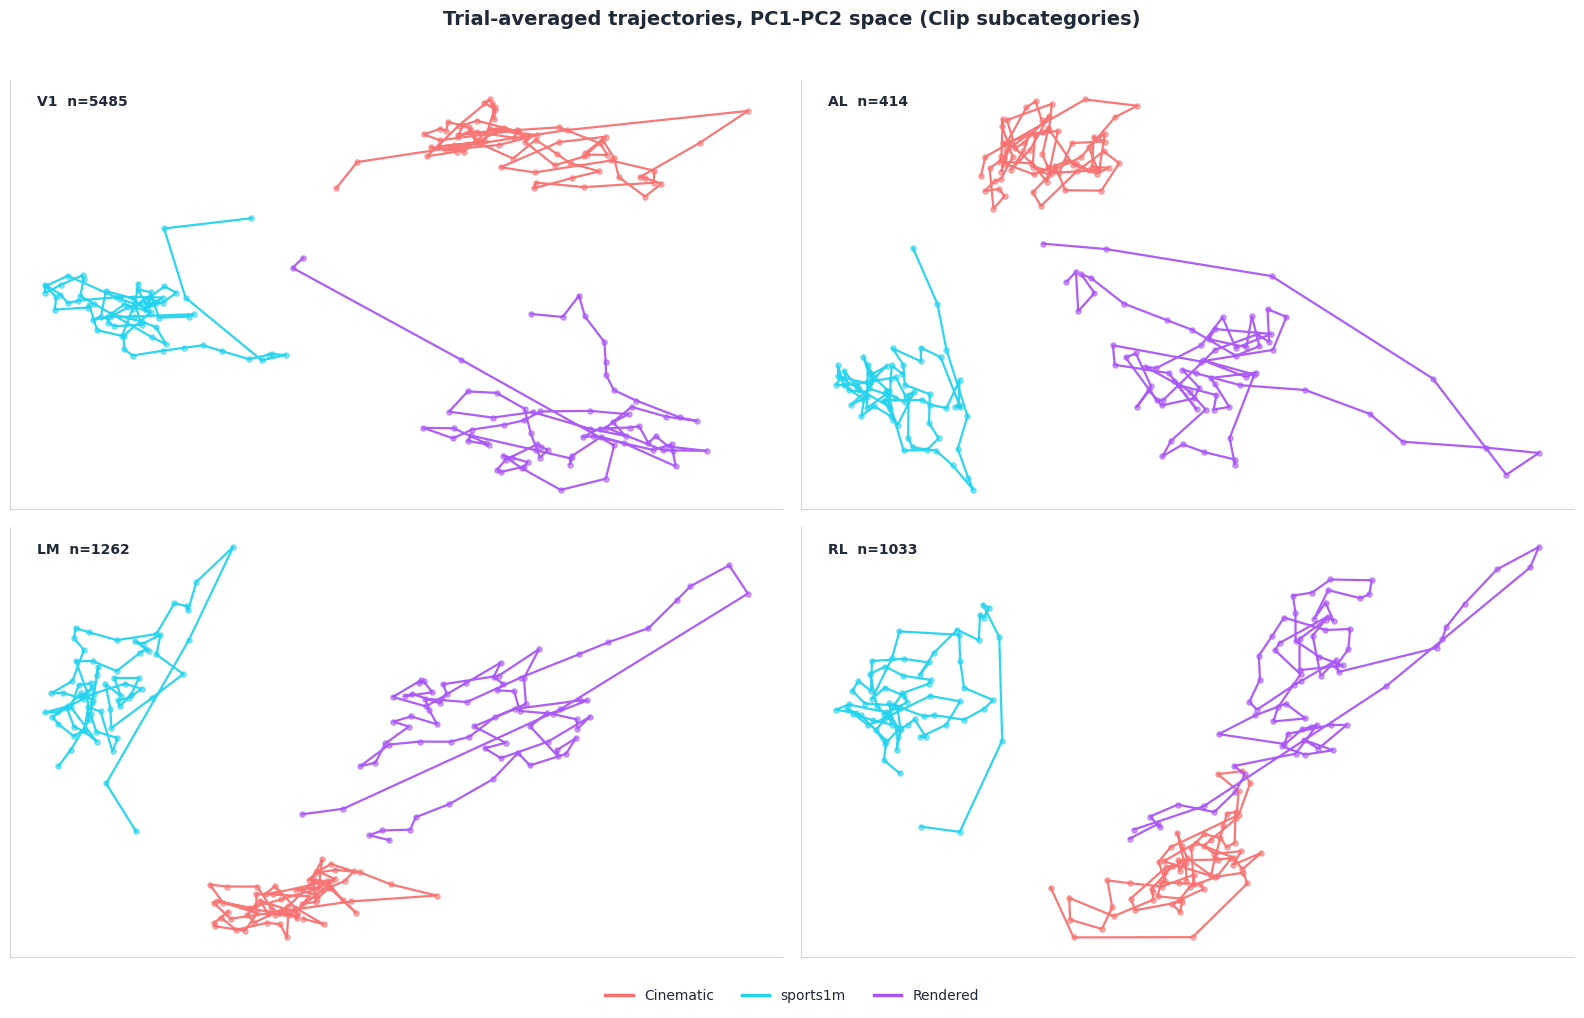

In [31]:
# 2×2 grid of per-area trajectories (PC1-PC2): slide-deck layout, experiment 3 categories.

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, area in zip(axes.flat, ["V1", "AL", "LM", "RL"]):
    res = all_area_results[area]
    stim_pcs = res["stim_pcs"]
    n_neurons = res["n_neurons"]

    for cat in o4.CATEGORY_ORDER:
        if cat not in stim_pcs:
            continue
        traj = stim_pcs[cat]
        ax.plot(
            traj[:, 0], traj[:, 1],
            color=o4.CATEGORY_COLORS[cat], linewidth=1.6, alpha=0.95,
        )
        # Subtle scatter overlay so the trajectory reads as a 'blob' on a slide.
        ax.scatter(
            traj[:, 0], traj[:, 1],
            color=o4.CATEGORY_COLORS[cat], s=14, alpha=0.55,
        )

    # Subtle thin border on all four sides.
    for spine in ax.spines.values():
        spine.set_linewidth(0.6)
        spine.set_color("#cccccc")

    # Strip axis chrome.
    ax.set_xticks([])
    ax.set_yticks([])

    # Area + neuron count in the top-left of the panel.
    ax.text(
        0.035, 0.965, f"{area}  n={n_neurons}",
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=10, fontweight="bold",
    )

# Figure-level title (small chart title, not a slide title).
fig.suptitle("Trial-averaged trajectories, PC1-PC2 space (Clip subcategories)",
             y=0.995)

# Single shared colour key at the bottom: no per-panel legends.
handles = [
    plt.Line2D([0], [0], color=o4.CATEGORY_COLORS[c], linewidth=2.5, label=c)
    for c in o4.CATEGORY_ORDER
]
fig.legend(
    handles=handles, loc="lower center", ncol=len(handles),
    fontsize=10, frameon=False, bbox_to_anchor=(0.5, -0.01),
)

fig.tight_layout(rect=(0, 0.03, 1, 0.98))
(FIGURES_DIR / "presentation").mkdir(exist_ok=True)
fig.savefig(FIGURES_DIR / "presentation" / "trajectories_2x2.png", dpi=150, bbox_inches="tight")
plt.show()

## Presentation figure: simple 2×2 category-trajectory grid

Plain 2×2 grid: one `plot_trajectory_2d` panel per cortical area (V1, AL, LM, RL), coloured by Clip subcategory via `o4.CATEGORY_COLORS` / `o4.CATEGORY_ORDER`. Same defaults as the experiment 2 simple grid (axis labels, variance %, frame markers, time annotations, per-panel legend), just with the new palette.

Saved as SVG (and PNG) to `figures/exp3_clip_categories/{SESSION}/presentation/`.

saved trajectories_2x2_simple.svg + .png to figures/exp3_clip_categories/7_5/presentation


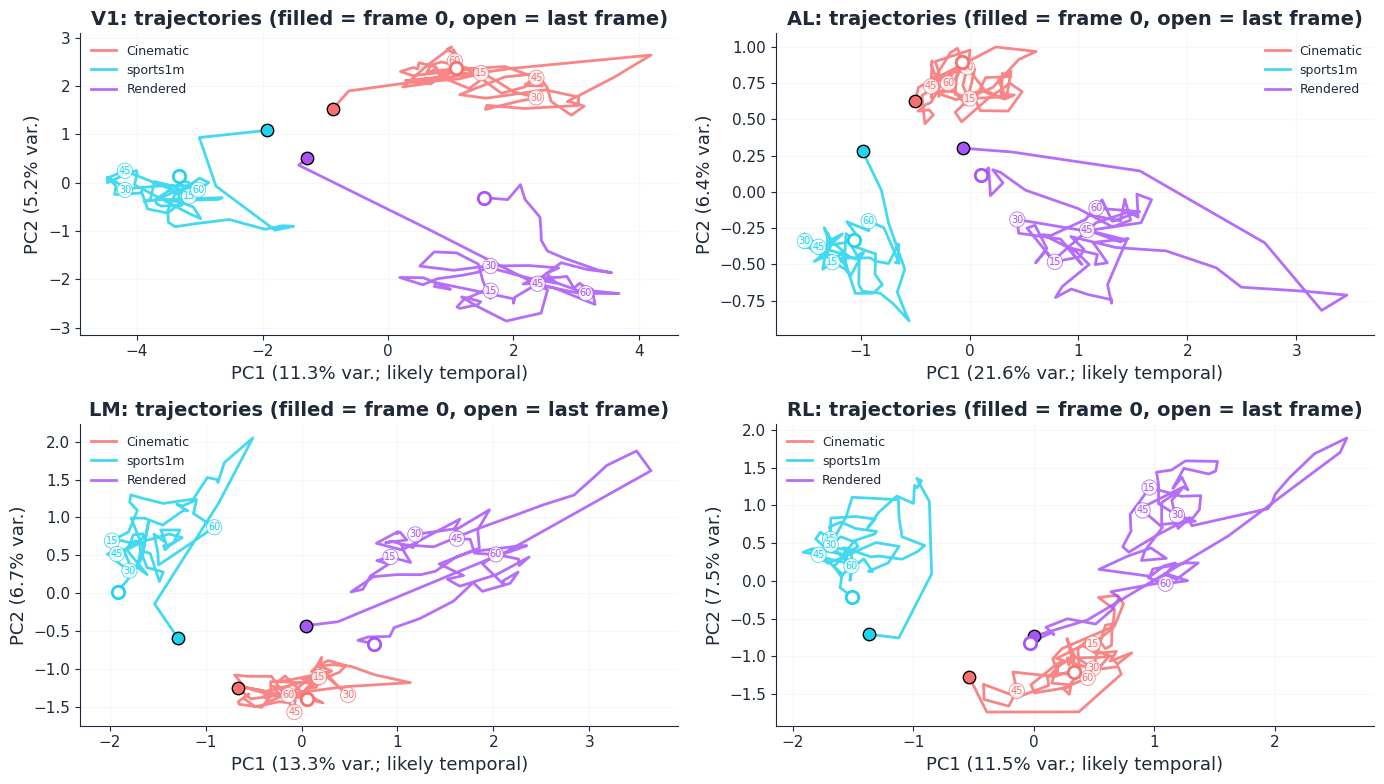

In [32]:
# Simple 2x2 grid of plot_trajectory_2d (experiment 3 categories), one per cortical area.

PRESENTATION_DIR = FIGURES_DIR / "presentation"
PRESENTATION_DIR.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, area in zip(axes.flat, ["V1", "AL", "LM", "RL"]):
    res = all_area_results[area]
    traj_utils.plot_trajectory_2d(
        res["stim_pcs"], area, res["pca"],
        palette=o4.CATEGORY_COLORS, stim_order=o4.CATEGORY_ORDER,
        ax=ax,
    )
fig.tight_layout()

fig.savefig(PRESENTATION_DIR / "trajectories_2x2_simple.svg",
            format="svg", bbox_inches="tight")
fig.savefig(PRESENTATION_DIR / "trajectories_2x2_simple.png",
            dpi=150, bbox_inches="tight")
print(f"saved trajectories_2x2_simple.svg + .png to {PRESENTATION_DIR}")
plt.show()

## Presentation figure: AL specialness under population matching

Grouped bar chart for the slide deck: per-area max trajectory distance for each of the three Clip subcategory pairs, **after** every area has been subsampled to AL's 414 neurons. AL is highlighted in amber in every group; V1/LM/RL in slate. Pulled live from `matched_results`: no hardcoded values. Saved as SVG + PNG to `figures/exp3_clip_categories/{SESSION}/presentation/`.

findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font f

Matched-population max distances (median across subsamples):
  Cinematic ↔ sports1m: V1=3.642  LM=3.759  RL=3.429  AL=3.710
  Cinematic ↔ Rendered: V1=3.522  LM=3.936  RL=3.814  AL=4.748
  sports1m ↔ Rendered: V1=3.553  LM=4.285  RL=3.938  AL=5.200


findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font f


saved al_specialness_matched.svg + .png to figures/exp3_clip_categories/7_5/presentation


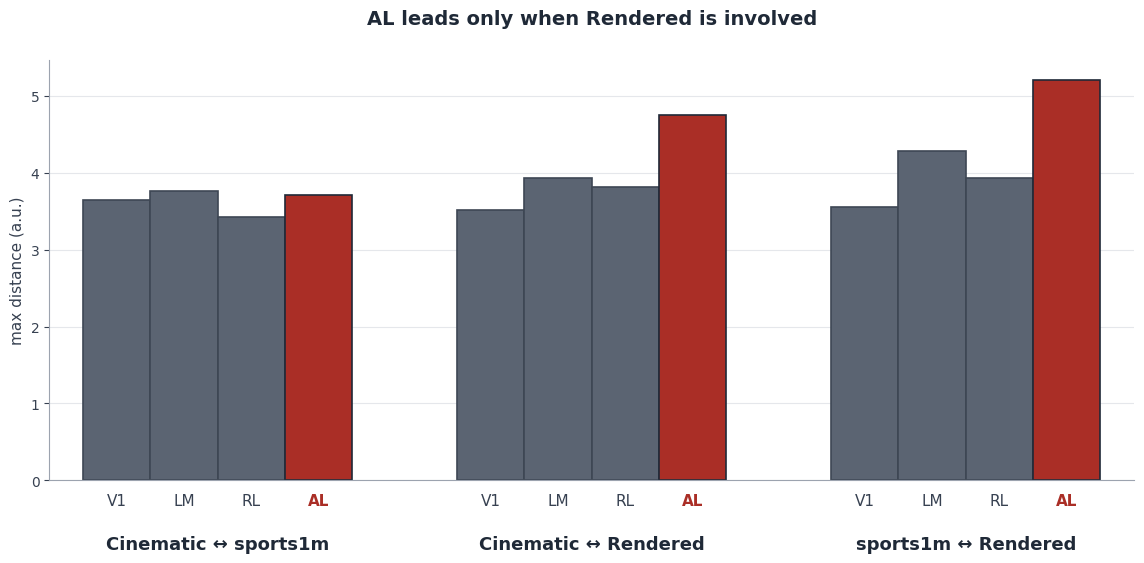

In [33]:
# AL specialness under population matching: grouped bar chart (3 pairs × 4 areas).
# Each area's bar = median (across subsamples) of the per-subsample max distance.
# AL has a single identity entry (already at 414 neurons); V1/LM/RL have 20 subsamples.

from matplotlib.transforms import blended_transform_factory

plt.rcParams["font.family"] = ["Inter", "DejaVu Sans", "sans-serif"]

PRESENTATION_DIR = FIGURES_DIR / "presentation"
PRESENTATION_DIR.mkdir(parents=True, exist_ok=True)

# 1) Build matched_distances live from matched_results.
pair_specs = [
    ("Cinematic", "sports1m",  "Cinematic ↔ sports1m"),
    ("Cinematic", "Rendered",  "Cinematic ↔ Rendered"),
    ("sports1m",  "Rendered",  "sports1m ↔ Rendered"),
]
PAIR_LABELS = [s[2] for s in pair_specs]
AREAS_ORDER = ["V1", "LM", "RL", "AL"]

matched_distances = {label: {} for _, _, label in pair_specs}
for a, b, label in pair_specs:
    pair_key = frozenset({a, b})
    for area in AREAS_ORDER:
        per_sub_max = np.array([
            s["distances_full"][pair_key].max()
            for s in matched_results[area]
        ])
        matched_distances[label][area] = float(np.median(per_sub_max))

# Sanity print before plotting.
print("Matched-population max distances (median across subsamples):")
for label in PAIR_LABELS:
    row = "  ".join(f"{a}={matched_distances[label][a]:.3f}" for a in AREAS_ORDER)
    print(f"  {label}: {row}")

# 2) Colour palette.
NEUTRAL        = "#5B6472"   # slate grey-blue (V1, LM, RL)
HIGHLIGHT      = "#AA2E26"   # deep red (AL, always)
NEUTRAL_EDGE   = "#3E4754"
HIGHLIGHT_EDGE = "#1F2937"

# 3) Layout.
n_groups = len(PAIR_LABELS)
n_per_group = len(AREAS_ORDER)
bar_width = 0.18
offsets = (np.arange(n_per_group) - (n_per_group - 1) / 2) * bar_width

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# 4) Bars: colour by area (AL = deep red, others = slate).
for i, label in enumerate(PAIR_LABELS):
    for j, area in enumerate(AREAS_ORDER):
        x = i + offsets[j]
        h = matched_distances[label][area]
        is_al = (area == "AL")
        ax.bar(
            x, h, width=bar_width,
            color=HIGHLIGHT if is_al else NEUTRAL,
            edgecolor=HIGHLIGHT_EDGE if is_al else NEUTRAL_EDGE,
            linewidth=1.2,
        )

# 5) Title + subtitle.                                          # ← NEW
ax.set_title(                                                   # ← NEW
    "AL leads only when Rendered is involved",                  # ← NEW
    fontsize=14, fontweight="bold", color="#1F2937",            # ← NEW
    loc="center", pad=26,                                         # ← NEW
)                                                               # ← NEW
                                                             # ← NEW

# 6) Spines + grid.
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#9CA3AF")
ax.spines["bottom"].set_color("#9CA3AF")
ax.yaxis.grid(True, color="#E5E7EB", linewidth=0.8)
ax.xaxis.grid(False)
ax.set_axisbelow(True)

# 7) Y-axis.
ax.set_ylabel("max distance (a.u.)", fontsize=11, color="#374151")
ax.tick_params(axis="y", colors="#374151", labelsize=10)
ax.set_ylim(bottom=0)

# 8) Two-tier x-axis labels (manual: we draw them instead of using xticklabels).
ax.set_xticks([])
ax.tick_params(axis="x", length=0)
ax.set_xlim(-0.45, n_groups - 1 + 0.45)

trans = blended_transform_factory(ax.transData, ax.transAxes)
for i, label in enumerate(PAIR_LABELS):
    # Per-bar area labels (AL bold deep-red; others slate regular).
    for j, area in enumerate(AREAS_ORDER):
        x = i + offsets[j]
        is_al = (area == "AL")
        ax.text(
            x, -0.03, area,
            transform=trans,
            ha="center", va="top",
            fontsize=11,
            color=HIGHLIGHT if is_al else "#374151",
            fontweight="bold" if is_al else "normal",
        )
    # Pair label centered under the group.
    ax.text(
        i, -0.13, label,
        transform=trans,
        ha="center", va="top",
        fontsize=13, fontweight="bold", color="#1F2937",
    )

plt.subplots_adjust(bottom=0.18)

# 9) Save SVG + PNG with explicit white backgrounds.
fig.savefig(
    PRESENTATION_DIR / "al_specialness_matched.svg",
    format="svg", bbox_inches="tight", facecolor="white",
)
fig.savefig(
    PRESENTATION_DIR / "al_specialness_matched.png",
    dpi=300, bbox_inches="tight", facecolor="white",
)
print(f"\nsaved al_specialness_matched.svg + .png to {PRESENTATION_DIR}")
plt.show()